# Hyperparameter Tuning - Optimización de Hiperparámetros

1. **Importaciones y Configuración**
2. **Carga y Preparación de Datos**
3. **Análisis Estadístico y Regresión Lineal** — Matriz de correlación y Regresión Lineal Múltiple
4. **Preparación de Features y Target**
5. **Hyperparameter Tuning - RandomizedSearchCV**
6. **Evaluación y Cross-Validation**
7. **Visualizaciones**
8. **Comparación Final: CV-5 KFold y Selección del Modelo**
9. **Diagnóstico del Modelo Final**
10. **Importancia de Variables y Explicabilidad**

---

## 1. Importaciones y Configuración

In [1]:
# Configuración del entorno Django
import os
import sys
import django

# Permitir Django ORM en Jupyter
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

from dotenv import load_dotenv

# Cargar .env desde la raíz del proyecto (TFM Repo/)
project_path = os.path.abspath('../..')
env_path = os.path.join(project_path, '.env')
load_dotenv(dotenv_path=env_path)

# DETECCIÓN AUTOMÁTICA DE ENTORNO
# Si POSTGRES_HOST=database (Docker), cambiar a localhost (ejecución local del notebook)
postgres_host = os.getenv('POSTGRES_HOST', 'localhost')
if postgres_host == 'database':
    postgres_host = 'localhost'
    print("Detectado entorno Docker, cambiando host a 'localhost' para notebook local")

os.environ['POSTGRES_HOST'] = postgres_host
os.environ['POSTGRES_PORT'] = os.getenv('POSTGRES_PORT', '')
os.environ['POSTGRES_DB'] = os.getenv('POSTGRES_DB', '')
os.environ['POSTGRES_USER'] = os.getenv('POSTGRES_USER', '')
os.environ['POSTGRES_PASSWORD'] = os.getenv('POSTGRES_PASSWORD', '')

# Path del proyecto
sys.path.insert(0, project_path)
sys.path.insert(0, os.path.join(project_path, 'backend'))

# Añadir ml_pipeline al path para importar ml_config
sys.path.insert(0, os.path.abspath('..'))

# Configurar Django
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'config.settings')
django.setup()

print("\nDjango configurado correctamente")
print(f"- PostgreSQL: {os.environ['POSTGRES_HOST']}:{os.environ['POSTGRES_PORT']}")
print(f"- Database: {os.environ['POSTGRES_DB']}")


Detectado entorno Docker, cambiando host a 'localhost' para notebook local

Django configurado correctamente
- PostgreSQL: localhost:5432
- Database: amsterdam_properties


In [2]:
import os
import random
import sys
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import statsmodels.api as sm
from scipy import stats
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from xgboost import XGBRegressor

# Módulos del proyecto
sys.path.insert(0, os.path.abspath('..'))
from ml_config import MLConfig
from modeling.model_trainer import ModelTrainer
from modeling.hyperparameter_tuner import HyperparameterTuner
from data_preparation.data_transformer import DataTransformer

# Configuración de visualización
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Seeds para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

---

## 2. Carga y Preparación de Datos

In [3]:
# CONFIGURACIÓN: Elegir fuente de datos
# Opciones: 'postgresql' o 'csv'
DATA_SOURCE = 'postgresql'  # Cambiar a 'csv' para leer desde archivo CSV

print(f"Fuente de datos configurada: {DATA_SOURCE}")

Fuente de datos configurada: postgresql


In [4]:
# CARGA DE DATOS
if DATA_SOURCE == 'postgresql':
    # Cargar desde PostgreSQL (Django ORM)
    from properties.models import Property

    # Cargar TODAS las propiedades (tanto activas como inactivas) con precio > 0
    properties = Property.objects.filter(price__gt=0)
    df_raw = pd.DataFrame(list(properties.values()))

    # Convertir Decimal a float
    decimal_columns = ['price', 'living_area', 'lot_area', 'latitude', 'longitude', 'predicted_price']
    for col in decimal_columns:
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].astype(float)

    print(f"- Cargadas {len(df_raw):,} propiedades desde PostgreSQL")

else:
    # Cargar desde CSV
    csv_path = MLConfig.get_csv_path()
    df_raw = pd.read_csv(csv_path)
    
    print(f"- Cargadas {len(df_raw):,} propiedades desde CSV")
    print(f"- Archivo: {csv_path}")

- Cargadas 5,265 propiedades desde PostgreSQL


In [5]:
# Transformar datos usando DataTransformer

transformer = DataTransformer(df_raw)
df_transformed = transformer.transform()


TRANSFORMACION DE DATOS:

[1/3] LIMPIEZA DE DATOS
- Duplicados eliminados: 0
- Propiedades invalidas filtradas: 129
- Outliers eliminados (IQR threshold=1.5): 768 (15.0%)
- Valores faltantes rellenados

[2/3] FEATURE ENGINEERING BÁSICO
- Feature basica creada: property_age
- Feature creada: amenity_score
- Features de ratios creadas: bedroom_ratio, bathroom_ratio, area_per_room, area_per_bedroom
- Features espaciales creadas: distance_to_center_km, is_central
- Features de barrio creadas desde datos oficiales WOZ Amsterdam

[3/3] ENCODING
- Encoding realizado: property_type (one-hot), energy_label
- Booleanos convertidos a 0/1

TRANSFORMACION COMPLETA
- Dataset final: 4368 filas (propiedades), 43 columnas


In [6]:
feature_columns = MLConfig.get_feature_columns()

# Entrenar solo con inactivas
df_train  = df_transformed[df_transformed['is_active'] == False].copy()
df_detect = df_transformed[df_transformed['is_active'] == True].copy()

print(f"- Propiedades inactivas (Entrenamiento): {len(df_train)}")
print(f"- Propiedades activas (Detección de oportunidades): {len(df_detect)}")

X = df_train[feature_columns].copy()
y = df_train['price']

- Propiedades inactivas (Entrenamiento): 3443
- Propiedades activas (Detección de oportunidades): 925


---

## 3. Análisis Estadístico y Regresión Lineal

### 3.1 Matriz de Correlación

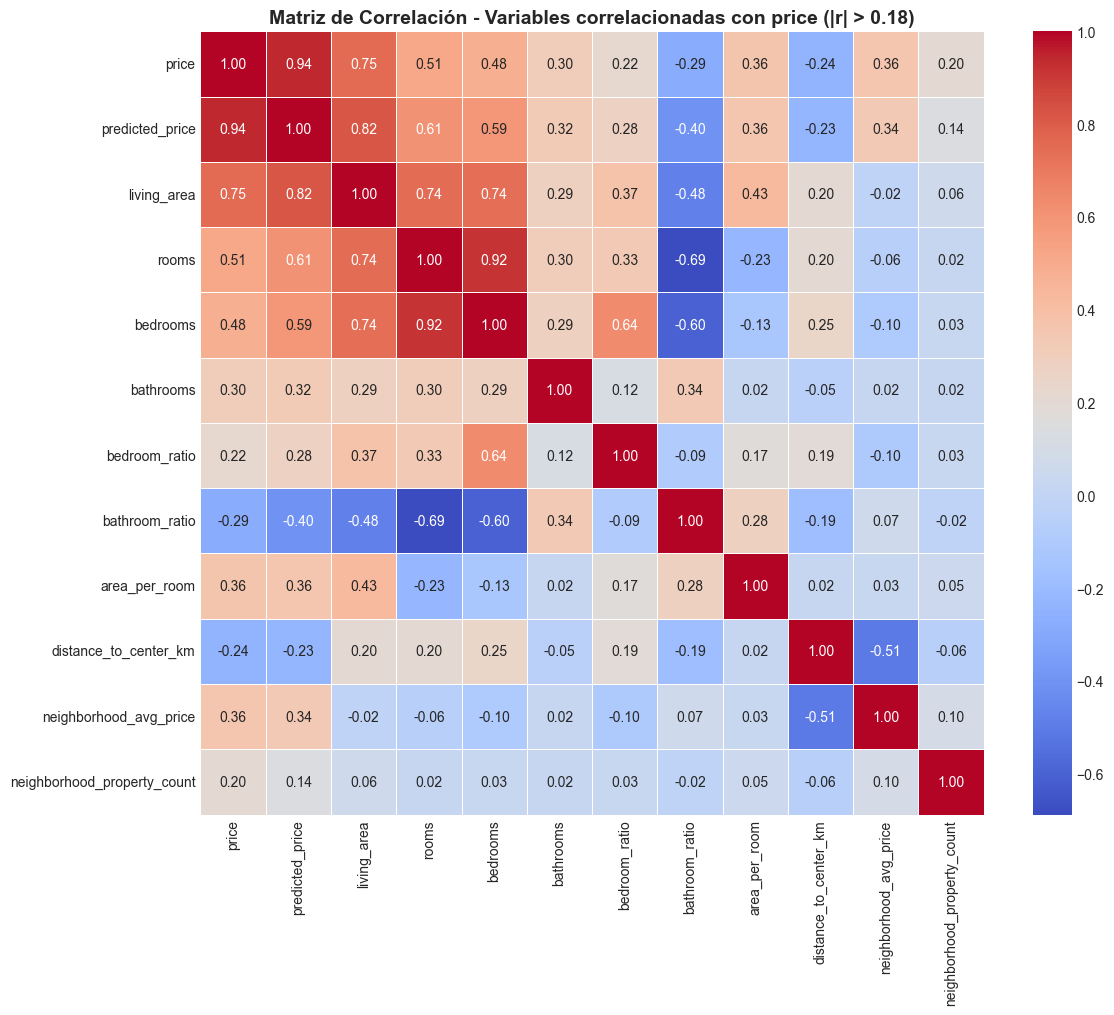


Variables altamente correlacionadas con price (|r| > 0.18):
  predicted_price                    : +0.9442
  living_area                        : +0.7513
  rooms                              : +0.5146
  bedrooms                           : +0.4811
  bathrooms                          : +0.3031
  bedroom_ratio                      : +0.2157
  bathroom_ratio                     : -0.2858
  area_per_room                      : +0.3635
  distance_to_center_km              : -0.2437
  neighborhood_avg_price             : +0.3559
  neighborhood_property_count        : +0.2032


In [7]:
def plot_high_corr_matrix(df, target_variable='price', threshold=0.3):
    """
    Calcular y graficar la matriz de correlación para variables altamente correlacionadas con la variable objetivo.

    Args:
        - df: DataFrame que contiene los datos.
        - target_variable: La variable objetivo para correlacionar (por defecto es 'price').
        - threshold: El umbral de correlación para considerar como "altamente correlacionada" (por defecto es 0.3).
    """
    # Seleccionar solo columnas numéricas
    df_numeric = df.select_dtypes(include=[np.number])

    # Matriz de correlación
    correlation_matrix = df_numeric.corr()

    # Identificar variables fuertemente correlacionadas con la variable objetivo
    target_correlation = correlation_matrix[target_variable]
    high_corr_vars = target_correlation[
        (target_correlation > threshold) | (target_correlation < -threshold)
    ].index

    # Subset de la matriz de correlación
    filtered_corr_matrix = correlation_matrix.loc[high_corr_vars, high_corr_vars]

    plt.figure(figsize=(12, 10))
    sns.heatmap(filtered_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
                cbar=True, square=True, linewidths=0.5)
    plt.title(f'Matriz de Correlación - Variables correlacionadas con {target_variable} (|r| > {threshold})',
            fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Tabla resumen
    print(f"\nVariables altamente correlacionadas con {target_variable} (|r| > {threshold}):")
    for var in high_corr_vars:
        if var != target_variable:
            corr_val = target_correlation[var]
            print(f"  {var:35s}: {corr_val:+.4f}")
    return target_correlation[high_corr_vars].sort_values(ascending=False)

high_corr = plot_high_corr_matrix(df_transformed, target_variable='price', threshold=0.18)

### 3.2 Regresión Lineal Múltiple

REGRESIÓN LINEAL MÚLTIPLE

R-squared:          0.7921
Adjusted R-squared: 0.7909

Significance: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1

                   Variable   Coefficient  Std_Error       P_value  CI_Lower  CI_Upper Significance
                  Intercept -2.697495e-16   0.007795  1.000000e+00 -0.015283  0.015283             
                living_area  8.373341e-01   0.034560 8.128637e-120  0.769574  0.905095          ***
                   bedrooms -2.811931e-01   0.046519  1.658209e-09 -0.372401 -0.189985          ***
     neighborhood_avg_price  2.632947e-01   0.010046 4.001890e-138  0.243597  0.282992          ***
      distance_to_center_km -2.578382e-01   0.011209 5.557177e-109 -0.279816 -0.235860          ***
neighborhood_property_count  1.163233e-01   0.008206  2.308005e-44  0.100234  0.132413          ***
           area_per_bedroom -1.093461e-01   0.038480  4.514440e-03 -0.184791 -0.033901           **
       energy_label_encoded  1.049792e-01   0.009733  1.07305

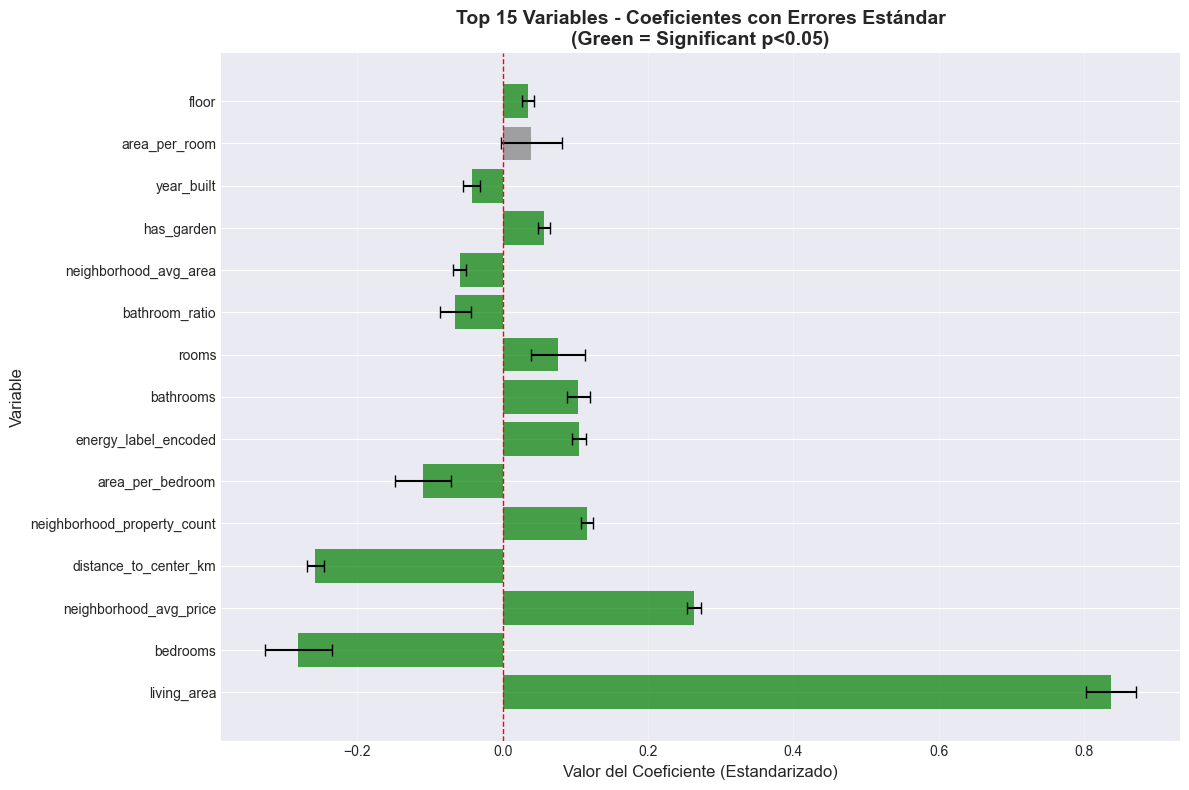

In [8]:
def multivariate_linear_regression(df, features, target='price', scale_features=True, scale_target=True):
    """Realizar regresión lineal múltiple con statsmodels para análisis de significancia estadística."""
    X = df[features].copy()
    y = df[target].copy()
    
    # LIMPIAR DATOS
    if 'floor' in X.columns:
        X['floor'] = X['floor'].fillna(0)
    
    if 'distance_to_center_km' in X.columns:
        median_dist = X['distance_to_center_km'].median()
        X['distance_to_center_km'] = X['distance_to_center_km'].fillna(median_dist)
    
    X = X.replace([np.inf, -np.inf], np.nan)
    for col in X.columns:
        if X[col].isna().sum() > 0:
            X[col] = X[col].fillna(X[col].median())
    
    X = X.loc[:, X.std() > 0]
    valid_features = list(X.columns)
    
    # Scale
    if scale_features:
        scaler_features = StandardScaler()
        X_scaled = scaler_features.fit_transform(X)
    else:
        X_scaled = X.values
    
    if scale_target:
        scaler_target = StandardScaler()
        y_scaled = scaler_target.fit_transform(y.values.reshape(-1, 1)).flatten()
    else:
        y_scaled = y.values
    
    # Añadir constante y ajustar
    X_with_const = sm.add_constant(X_scaled)
    model = sm.OLS(y_scaled, X_with_const)
    results = model.fit()
    
    # Resultados
    coefficients = results.params
    standard_errors = results.bse
    p_values = results.pvalues
    conf_int = results.conf_int(alpha=0.05)
    
    variable_names = ['Intercept'] + valid_features
    summary_df = pd.DataFrame({
        'Variable': variable_names,
        'Coefficient': list(coefficients),
        'Std_Error': list(standard_errors),
        'P_value': list(p_values),
        'CI_Lower': list(conf_int[:, 0]),
        'CI_Upper': list(conf_int[:, 1])
    })
    
    def significance_stars(p_value):
        if p_value < 0.001:
            return '***'
        elif p_value < 0.01:
            return '**'
        elif p_value < 0.05:
            return '*'
        elif p_value < 0.1:
            return '.'
        else:
            return ''
    
    summary_df['Significance'] = summary_df['P_value'].apply(significance_stars)
    summary_df_sorted = pd.concat([
        summary_df[summary_df['Variable'] == 'Intercept'],
        summary_df[summary_df['Variable'] != 'Intercept'].sort_values('Coefficient', key=abs, ascending=False)
    ])
    
    r2 = results.rsquared
    r2_adj = results.rsquared_adj
    
    print("REGRESIÓN LINEAL MÚLTIPLE")
    print(f"\nR-squared:          {r2:.4f}")
    print(f"Adjusted R-squared: {r2_adj:.4f}")
    print(f"\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1")
    print("\n" + summary_df_sorted.to_string(index=False))
    print("\n")
    
    summary_no_intercept = summary_df_sorted[summary_df_sorted['Variable'] != 'Intercept'].head(15)
    plt.figure(figsize=(12, 8))
    colors = ['green' if p < 0.05 else 'gray' for p in summary_no_intercept['P_value']]
    plt.barh(summary_no_intercept['Variable'], summary_no_intercept['Coefficient'], 
            xerr=summary_no_intercept['Std_Error'], capsize=4, color=colors, alpha=0.7)
    plt.xlabel('Valor del Coeficiente (Estandarizado)', fontsize=12)
    plt.ylabel('Variable', fontsize=12)
    plt.title('Top 15 Variables - Coeficientes con Errores Estándar\n(Green = Significant p<0.05)', 
            fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return summary_df_sorted, r2, r2_adj

# Usar SOLO df_train (propiedades inactivas)
summary_df, r2, r2_adj = multivariate_linear_regression(
    df_train, 
    feature_columns, 
    target='price',
    scale_features=True, 
    scale_target=True
)

---

## 4. Preparación de Features y Target

In [9]:
# Preparar X e y
target_column = 'price'

X = df_train[feature_columns].copy()
y = df_train[target_column].copy()

# Aplicar log-transform si está configurado en MLConfig
if MLConfig.LOG_TRANSFORM_TARGET:
    print("Log-transform del target (precio) (MLConfig.LOG_TRANSFORM_TARGET=1)")
    y = np.log1p(y)
    inverse_transform = np.expm1
else:
    print("Target SIN log-transform (precio) (MLConfig.LOG_TRANSFORM_TARGET=0)")
    inverse_transform = lambda v: v

print(f"\nDataset: {len(X)} muestras, {len(feature_columns)} características")
print(f"\nAnálisis de valores nulos:")
print(f"- NaN en X: {X.isna().sum().sum()}")
print(f"- Inf en X: {np.isinf(X).sum().sum()}")
print(f"- NaN en y: {y.isna().sum()}")
print(f"- Inf en y: {np.isinf(y).sum()}")

Log-transform del target (precio) (MLConfig.LOG_TRANSFORM_TARGET=1)

Dataset: 3443 muestras, 23 características

Análisis de valores nulos:
- NaN en X: 0
- Inf en X: 0
- NaN en y: 0
- Inf en y: 0


In [10]:
# Limpieza de datos
print("LIMPIEZA DE DATOS\n")

# Rellenar floor con 0 (planta baja por defecto)
if 'floor' in X.columns:
    nan_count = X['floor'].isna().sum()
    if nan_count > 0:
        X['floor'] = X['floor'].fillna(0)
        print(f"- floor: {nan_count} NaN → Rellenados con 0")
    else:
        print(f"- floor: Sin NaN")

# Rellenar distance_to_center_km con la mediana
if 'distance_to_center_km' in X.columns:
    nan_count = X['distance_to_center_km'].isna().sum()
    if nan_count > 0:
        median_dist = X['distance_to_center_km'].median()
        X['distance_to_center_km'] = X['distance_to_center_km'].fillna(median_dist)
        print(f"- distance_to_center_km: {nan_count} NaN → Rellenados con mediana {median_dist:.2f}")
    else:
        print(f"- distance_to_center_km: Sin NaN")

# Reemplazar Inf con NaN y luego con mediana por columna
inf_total = np.isinf(X).sum().sum()
if inf_total > 0:
    X = X.replace([np.inf, -np.inf], np.nan)
    print(f"\n- Inf: {inf_total} → Convertidos a NaN")
    for col in X.columns:
        if X[col].isna().sum() > 0:
            X[col] = X[col].fillna(X[col].median())
    print(f"- NaN rellenados con medianas")
else:
    print(f"\n- Sin valores Inf")

print(f"\n- Limpieza completada: {len(X)} muestras")

LIMPIEZA DE DATOS

- floor: Sin NaN
- distance_to_center_km: Sin NaN

- Sin valores Inf

- Limpieza completada: 3443 muestras


In [11]:
# Verificación final y división train/test
print("POST-LIMPIEZA:\n")

nan_x = X.isna().sum().sum()
inf_x = np.isinf(X).sum().sum()
nan_y = y.isna().sum()
inf_y = np.isinf(y).sum()

status_x = "LIMPIO" if (nan_x == 0 and inf_x == 0) else f"Error: ({nan_x} NaN, {inf_x} Inf)"
status_y = "LIMPIO" if (nan_y == 0 and inf_y == 0) else f"Error: ({nan_y} NaN, {inf_y} Inf)"

print(f"X (features): {status_x}")
print(f"y (target):   {status_y}")

print(f"\nTotal: {len(X)} muestras, {len(X.columns)} features")

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"con:")
print(f"- Train: {len(X_train)} muestras ({len(X_train)/len(X)*100:.1f}%)")
print(f"- Test:  {len(X_test)} muestras ({len(X_test)/len(X)*100:.1f}%)")

POST-LIMPIEZA:

X (features): LIMPIO
y (target):   LIMPIO

Total: 3443 muestras, 23 features
con:
- Train: 2754 muestras (80.0%)
- Test:  689 muestras (20.0%)


---

## 5. Hyperparameter Tuning - RandomizedSearchCV

### 5.1 Decision Tree Baseline

In [12]:
# Decision Tree como baseline simple
# Si LOG_TRANSFORM_TARGET=1, y_train/y_test están en log → Se convierten a € para métricas interpretables
print("-"*80)
print("DECISION TREE BASELINE")
print("-"*80)

dt_model = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=30,
    min_samples_leaf=15,
    random_state=42
)

# Entrenar
dt_model.fit(X_train, y_train)

# Predicciones (en escala de entrenamiento: log si LOG_TRANSFORM_TARGET=1)
y_pred_train_dt_raw = dt_model.predict(X_train)
y_pred_test_dt_raw = dt_model.predict(X_test)

# Convertir a € para métricas interpretables
y_train_eur = inverse_transform(y_train)
y_test_eur = inverse_transform(y_test)
y_pred_train_dt = inverse_transform(y_pred_train_dt_raw)
y_pred_test_dt = inverse_transform(y_pred_test_dt_raw)

# Métricas - Train (en €)
r2_train_dt = r2_score(y_train_eur, y_pred_train_dt)
rmse_train_dt = np.sqrt(mean_squared_error(y_train_eur, y_pred_train_dt))
mae_train_dt = mean_absolute_error(y_train_eur, y_pred_train_dt)
mape_train_dt = mean_absolute_percentage_error(y_train_eur, y_pred_train_dt)
me_train_dt = np.mean(y_pred_train_dt - y_train_eur)
mpe_train_dt = np.mean((y_pred_train_dt - y_train_eur) / y_train_eur)

# Métricas - Test (en €)
r2_test_dt = r2_score(y_test_eur, y_pred_test_dt)
rmse_test_dt = np.sqrt(mean_squared_error(y_test_eur, y_pred_test_dt))
mae_test_dt = mean_absolute_error(y_test_eur, y_pred_test_dt)
mape_test_dt = mean_absolute_percentage_error(y_test_eur, y_pred_test_dt)
me_test_dt = np.mean(y_pred_test_dt - y_test_eur)
mpe_test_dt = np.mean((y_pred_test_dt - y_test_eur) / y_test_eur)

print(f"\nResultados de Decision Tree (métricas en €):")
print(f"- R² (Train): {r2_train_dt:.4f}")
print(f"- R² (Test): {r2_test_dt:.4f}")
print(f"- RMSE (Train): €{rmse_train_dt:,.0f}")
print(f"- RMSE (Test):  €{rmse_test_dt:,.0f}")
print(f"- MAE (Train):  €{mae_train_dt:,.0f}")
print(f"- MAE (Test): €{mae_test_dt:,.0f}")
print(f"- MAPE (Train): {mape_train_dt*100:.2f}%")
print(f"- MAPE (Test):  {mape_test_dt*100:.2f}%")
print(f"- ME (Train): €{me_train_dt:,.0f}")
print(f"- ME (Test): €{me_test_dt:,.0f}")
print(f"- MPE (Train):  {mpe_train_dt*100:.2f}%")
print(f"- MPE (Test): {mpe_test_dt*100:.2f}%")
print(f"- Overfitting Gap (R²): {r2_train_dt - r2_test_dt:+.4f}")
print("\nINFO: Decision Tree como baseline para la comparación con modelos más complejos")

--------------------------------------------------------------------------------
DECISION TREE BASELINE
--------------------------------------------------------------------------------

Resultados de Decision Tree (métricas en €):
- R² (Train): 0.8348
- R² (Test): 0.8063
- RMSE (Train): €90,416
- RMSE (Test):  €104,875
- MAE (Train):  €63,030
- MAE (Test): €70,256
- MAPE (Train): 10.16%
- MAPE (Test):  10.68%
- ME (Train): €-5,716
- ME (Test): €-20,385
- MPE (Train):  0.90%
- MPE (Test): -0.85%
- Overfitting Gap (R²): +0.0285

INFO: Decision Tree como baseline para la comparación con modelos más complejos


### 5.2 Modelos Lineales Regularizados (Ridge, Lasso, ElasticNet)

**Modelos de regresión lineal con regularización: Ridge (L2), Lasso (L1) y ElasticNet**

Uso de **RandomizedSearchCV** para tunear el parámetro de regularización `alpha`.

In [13]:
print("-"*80)
print("MODELOS LINEALES REGULARIZADOS - RandomizedSearchCV (métricas en €)")
print("-"*80)

# Inicializar tuner (usa MLConfig.N_ITER_TUNING por defecto)
linear_tuner = HyperparameterTuner(cv=5, n_jobs=-1, verbose=1)

# Modelos lineales a tunear
linear_models = ['Ridge', 'Lasso', 'ElasticNet']

linear_results = {}

for model_name in linear_models:
    print(f"\n{'-'*80}")
    print(f"Optimizando modelo: {model_name}")
    print(f"{'-'*80}")
    
    # Tunear usando HyperparameterTuner
    # El tuner aplica RobustScaler SOLO sobre X
    best_model, best_params, results = linear_tuner.tune(
        model_name,
        X_train,
        y_train,
        X_test,
        y_test
    )
    
    # El modelo devuelto espera datos ESCALADOS (el scaler está en results['scaler'])
    scaler = results.get('scaler', None)
    
    if scaler is not None:
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        y_pred_train_raw = best_model.predict(X_train_scaled)
        y_pred_test_raw = best_model.predict(X_test_scaled)
    else:
        y_pred_train_raw = best_model.predict(X_train)
        y_pred_test_raw = best_model.predict(X_test)
    
    # Convertir a € para métricas interpretables
    y_train_eur = inverse_transform(y_train)
    y_test_eur = inverse_transform(y_test)
    y_pred_train_eur = inverse_transform(y_pred_train_raw)
    y_pred_test_eur = inverse_transform(y_pred_test_raw)
    
    # Métricas en €
    r2_train = r2_score(y_train_eur, y_pred_train_eur)
    r2_test = r2_score(y_test_eur, y_pred_test_eur)
    rmse_test = np.sqrt(mean_squared_error(y_test_eur, y_pred_test_eur))
    mae_test = mean_absolute_error(y_test_eur, y_pred_test_eur)
    mape_test = mean_absolute_percentage_error(y_test_eur, y_pred_test_eur)
    me_test = np.mean(y_pred_test_eur - y_test_eur)
    mpe_test = np.mean((y_pred_test_eur - y_test_eur) / y_test_eur)
    
    linear_results[model_name] = {
        'model': best_model,
        'best_params': best_params,
        'cv_score': results['best_cv_score'],
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_test': rmse_test,
        'mae_test': mae_test,
        'mape_test': mape_test,
        'me_test': me_test,
        'mpe_test': mpe_test,
        'scaler': scaler
    }
    
    print(f"\nMejores parámetros: {best_params}")
    print(f"- R² (CV, escala entrenamiento): {results['best_cv_score']:.4f}")
    print(f"- R² (Train, €): {r2_train:.4f}")
    print(f"- R² (Test, €): {r2_test:.4f}")
    print(f"- RMSE: €{rmse_test:,.0f}")
    print(f"- MAE: €{mae_test:,.0f}")
    print(f"- MAPE: {mape_test*100:.2f}%")

print(f"\n{'-'*80}")
print("Comparación final de modelos lineales (en €)")
print("-"*80)

for name, res in linear_results.items():
    print(f"- {name}: R²(Test)={res['r2_test']:.4f}, MAPE={res['mape_test']*100:.2f}%, RMSE=€{res['rmse_test']:,.0f}")

--------------------------------------------------------------------------------
MODELOS LINEALES REGULARIZADOS - RandomizedSearchCV (métricas en €)
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Optimizando modelo: Ridge
--------------------------------------------------------------------------------

Optimizando modelo: Ridge
- Espacio: 15 combinaciones posibles
- Iteraciones: 15 (RandomizedSearchCV)
- CV: 5 folds
- Mejores parámetros: {'max_iter': 1000, 'alpha': 1.0}
- R2 CV: 0.8047
- Tiempo: 12.7s
- R2 Test: 0.7881 (€)
- RMSE Test: €109,685
- MAE Test: €74,276

Mejores parámetros: {'max_iter': 1000, 'alpha': 1.0}
- R² (CV, escala entrenamiento): 0.8047
- R² (Train, €): 0.7813
- R² (Test, €): 0.7881
- RMSE: €109,685
- MAE: €74,276
- MAPE: 11.57%

--------------------------------------------------------------------------------
Optimizando modelo: Lasso
-----------------

### 5.3 Análisis de Hiperparámetros - Impacto de n_estimators y max_depth

**Entender cómo diferentes combinaciones de `n_estimators` y `max_depth` afectan el MAPE para modelos tree-based.**

ANÁLISIS DE HIPERPARÁMETROS: n_estimators vs max_depth (métricas en €)


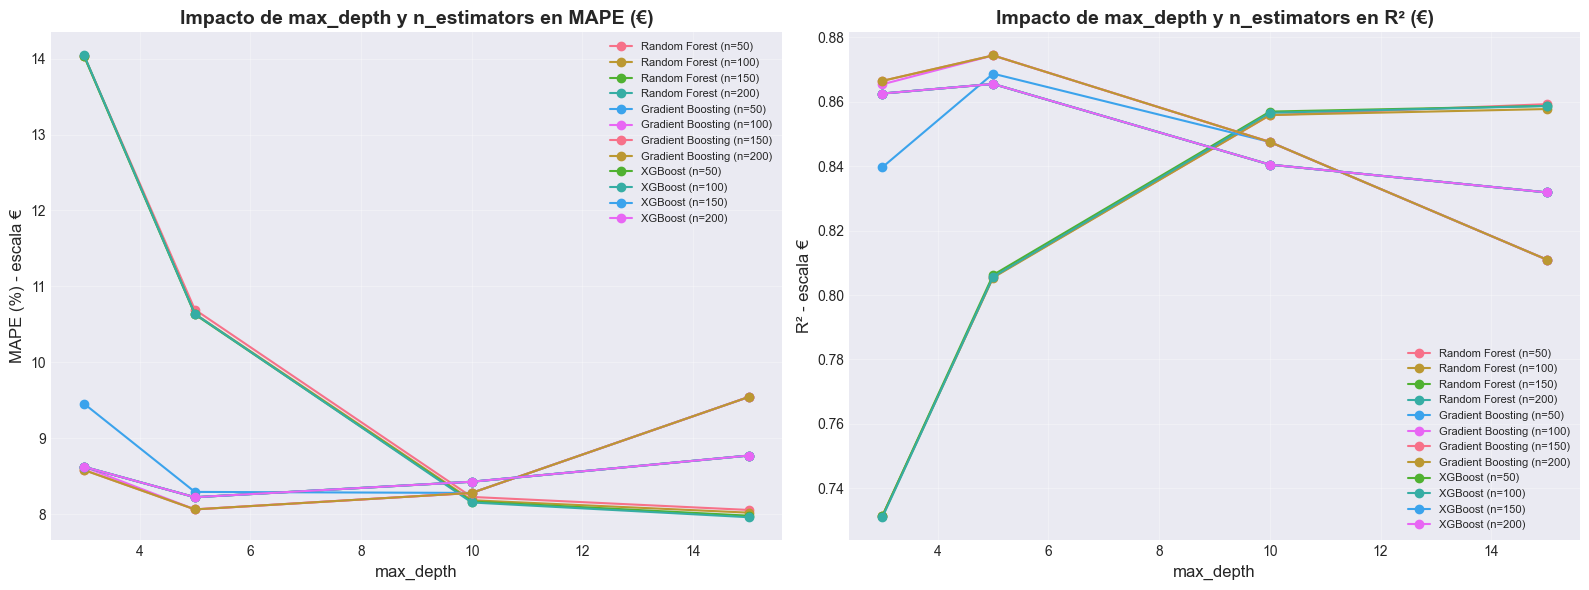



MEJORES COMBINACIONES POR MODELO (por MAPE en €):
- Random Forest: n_estimators=200, max_depth=15 → MAPE=7.96%, R²=0.8587
- Gradient Boosting: n_estimators=100, max_depth= 5 → MAPE=8.07%, R²=0.8744
- XGBoost: n_estimators= 50, max_depth= 5 → MAPE=8.23%, R²=0.8656


In [14]:
def evaluate_hyperparameters_impact(
    X_train, y_train, X_test, y_test,
    n_estimators_values=[50, 100, 150, 200],
    max_depth_values=[3, 5, 10, 15],
    models_to_evaluate=['Random Forest', 'Gradient Boosting', 'XGBoost']):
    """
    Evaluar el efecto de n_estimators y max_depth en MAPE para modelos basados en árboles.
    Métricas calculadas en € (escala interpretable) por inverse_transform.
    
    Sin leakage: XGBoost usa split interno del train para early stopping (15%), no el test.
    """
    from sklearn.model_selection import train_test_split
    results = []
    
    for model_name in models_to_evaluate:
        for n_estimators in n_estimators_values:
            for max_depth in max_depth_values:
                if model_name == 'Random Forest':
                    model = RandomForestRegressor(
                        n_estimators=n_estimators, 
                        max_depth=max_depth, 
                        random_state=42,
                        n_jobs=-1
                    )
                elif model_name == 'Gradient Boosting':
                    model = GradientBoostingRegressor(
                        n_estimators=n_estimators, 
                        max_depth=max_depth, 
                        random_state=42,
                        validation_fraction=0.1,
                        n_iter_no_change=10,
                        tol=1e-4
                    )
                elif model_name == 'XGBoost':
                    model = XGBRegressor(
                        n_estimators=n_estimators, 
                        max_depth=max_depth, 
                        random_state=42,
                        verbosity=0,
                        n_jobs=-1,
                        early_stopping_rounds=10,
                        eval_metric='mae'
                    )
                else:
                    continue
                
                # Entrenar - XGBoost usa split INTERNO del train para early stopping (sin leakage)
                if model_name == 'XGBoost':
                    X_tr, X_val, y_tr, y_val = train_test_split(
                        X_train, y_train, test_size=0.15, random_state=42
                    )
                    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
                else:
                    model.fit(X_train, y_train)
                
                # Predecir
                y_pred_raw = model.predict(X_test)
                
                # Convertir a € para métricas interpretables
                y_test_eur = inverse_transform(y_test)
                y_pred_eur = inverse_transform(y_pred_raw)
                
                # Métricas en €
                mape = mean_absolute_percentage_error(y_test_eur, y_pred_eur)
                r2 = r2_score(y_test_eur, y_pred_eur)
                
                results.append({
                    'Model': model_name,
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'MAPE': mape * 100,
                    'R2': r2
                })
    
    results_df = pd.DataFrame(results)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # MAPE plot
    for model_name in models_to_evaluate:
        subset = results_df[results_df['Model'] == model_name]
        for n_est in n_estimators_values:
            subset_n = subset[subset['n_estimators'] == n_est]
            axes[0].plot(
                subset_n['max_depth'], 
                subset_n['MAPE'], 
                marker='o',
                label=f'{model_name} (n={n_est})'
            )
    
    axes[0].set_xlabel('max_depth', fontsize=12)
    axes[0].set_ylabel('MAPE (%) - escala €', fontsize=12)
    axes[0].set_title('Impacto de max_depth y n_estimators en MAPE (€)', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=8, loc='best')
    axes[0].grid(True, alpha=0.3)
    
    # R² plot
    for model_name in models_to_evaluate:
        subset = results_df[results_df['Model'] == model_name]
        for n_est in n_estimators_values:
            subset_n = subset[subset['n_estimators'] == n_est]
            axes[1].plot(
                subset_n['max_depth'], 
                subset_n['R2'], 
                marker='o',
                label=f'{model_name} (n={n_est})'
            )
    
    axes[1].set_xlabel('max_depth', fontsize=12)
    axes[1].set_ylabel('R² - escala €', fontsize=12)
    axes[1].set_title('Impacto de max_depth y n_estimators en R² (€)', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=8, loc='best')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n")
    print("MEJORES COMBINACIONES POR MODELO (por MAPE en €):")
    for model_name in models_to_evaluate:
        subset = results_df[results_df['Model'] == model_name]
        best = subset.loc[subset['MAPE'].idxmin()]
        print(f"- {model_name}: n_estimators={best['n_estimators']:3.0f}, max_depth={best['max_depth']:2.0f} → MAPE={best['MAPE']:.2f}%, R²={best['R2']:.4f}")
    
    return results_df

print("ANÁLISIS DE HIPERPARÁMETROS: n_estimators vs max_depth (métricas en €)")

hyperparams_df = evaluate_hyperparameters_impact(
    X_train, y_train, X_test, y_test,
    n_estimators_values=[50, 100, 150, 200],
    max_depth_values=[3, 5, 10, 15],
    models_to_evaluate=['Random Forest', 'Gradient Boosting', 'XGBoost']
)


Efecto de 'max_depth' en Random_Forest:
- max_depth=3 -> R2=0.7264 (±0.0273)
- max_depth=5 -> R2=0.8100 (±0.0307)
- max_depth=8 -> R2=0.8505 (±0.0238)
- max_depth=12 -> R2=0.8554 (±0.0234)
- max_depth=20 -> R2=0.8550 (±0.0236)

Efecto de 'n_estimators' en Random_Forest:
- n_estimators=50 -> R2=0.8518 (±0.0234)
- n_estimators=100 -> R2=0.8528 (±0.0231)
- n_estimators=200 -> R2=0.8547 (±0.0237)
- n_estimators=350 -> R2=0.8547 (±0.0233)
- n_estimators=500 -> R2=0.8549 (±0.0230)

Efecto de 'max_depth' en Gradient_Boosting:
- max_depth=2 -> R2=0.8503 (±0.0375)
- max_depth=3 -> R2=0.8616 (±0.0345)
- max_depth=5 -> R2=0.8767 (±0.0215)
- max_depth=8 -> R2=0.8754 (±0.0182)

Efecto de 'learning_rate' en Gradient_Boosting:
- learning_rate=0.01 -> R2=0.8615 (±0.0210)
- learning_rate=0.05 -> R2=0.8767 (±0.0215)
- learning_rate=0.1 -> R2=0.8774 (±0.0199)
- learning_rate=0.2 -> R2=0.8738 (±0.0185)

Efecto de 'max_depth' en XGBoost:
- max_depth=4 -> R2=0.8814 (±0.0190)
- max_depth=6 -> R2=0.8858 (±0.

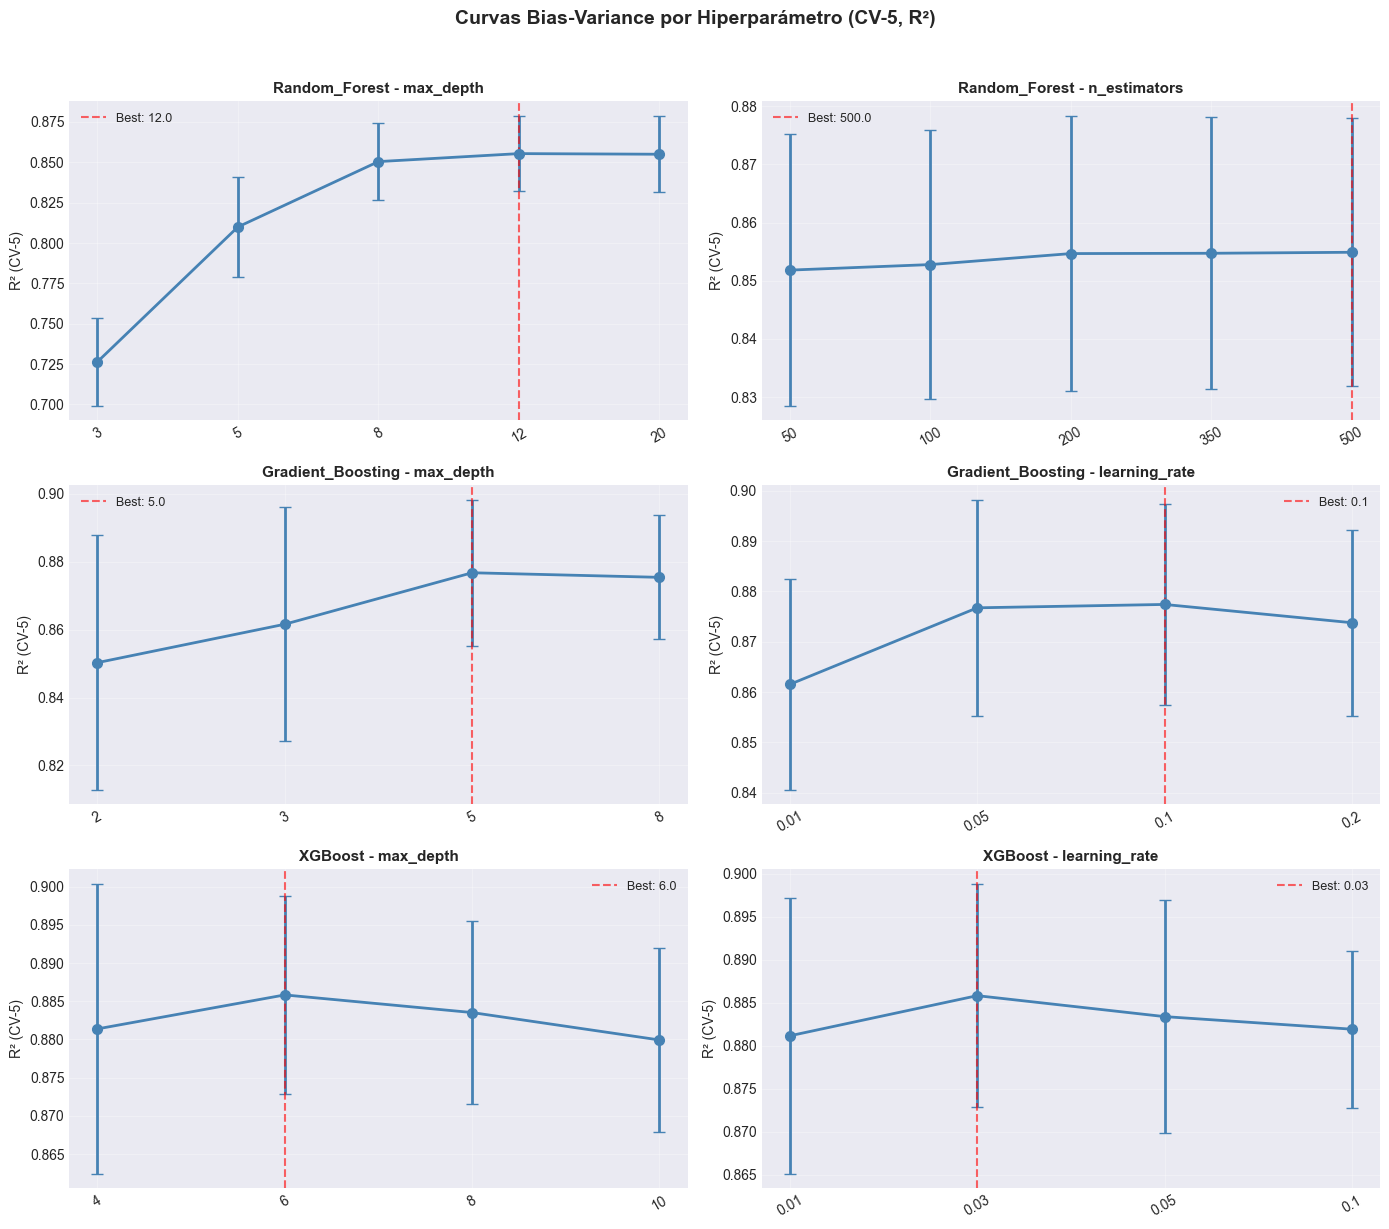

In [15]:
# Análisis de impacto de hiperparámetros con ModelTrainer.analyze_hyperparameter_effect()
# Muestra la curva bias-variance para parámetros clave de los modelos tree-based.

# Iniciar trainer y cargar configs
trainer_hp = ModelTrainer()
trainer_hp.models = MLConfig.get_model_configs()

# Parámetros a analizar
hp_analysis = {
    'Random_Forest':    [('max_depth',    [3, 5, 8, 12, 20]),
                         ('n_estimators', [50, 100, 200, 350, 500])],
    'Gradient_Boosting':[('max_depth',    [2, 3, 5, 8]),
                         ('learning_rate',[0.01, 0.05, 0.1, 0.2])],
    'XGBoost':          [('max_depth',    [4, 6, 8, 10]),
                         ('learning_rate',[0.01, 0.03, 0.05, 0.1])],
}

results_by_param = {}
for model_name, params in hp_analysis.items():
    for param_name, values in params:
        key = f'{model_name} - {param_name}'
        df_res = trainer_hp.analyze_hyperparameter_effect(
            model_name, param_name, values, X, y, metric='r2', cv=5
        )
        results_by_param[key] = df_res

# Visualización: Curva por combinación modelo/parámetro
n_rows = len(hp_analysis)
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, (key, df_res) in enumerate(results_by_param.items()):
    ax = axes[i]
    x_pos = range(len(df_res))
    ax.errorbar(x_pos, df_res['metric_mean'], yerr=df_res['metric_std'],
                fmt='o-', capsize=4, color='steelblue', linewidth=2, markersize=7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in df_res['param_value']], rotation=30)
    model_n, param_n = key.split(' - ')
    ax.set_title(f'{model_n} - {param_n}', fontsize=11, fontweight='bold')
    ax.set_ylabel('R² (CV-5)')
    ax.grid(alpha=0.3)
    # Marcar el mejor valor en rojo
    best_idx = df_res['metric_mean'].idxmax()
    ax.axvline(x=best_idx, color='red', linestyle='--', alpha=0.6,
               label=f'Best: {df_res.iloc[best_idx]["param_value"]}')
    ax.legend(fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Curvas Bias-Variance por Hiperparámetro (CV-5, R²)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Tree-based Models Principales (Random Forest, Gradient Boosting, XGBoost)

In [16]:
# Inicializar HyperparameterTuner
tuner = HyperparameterTuner()

# Modelos a tunear
# Los baselines, Linear_Regression y Stacking NO se tunean.

models_to_tune = [
    'Ridge', 'Lasso', 'ElasticNet',
    'Decision_Tree',
    'Random_Forest', 'Extra_Trees',
    'Gradient_Boosting',
    'XGBoost', 'LightGBM',
]

print(f'- Modelos seleccionados para tuning: {models_to_tune}')
print(f'- N_ITER_TUNING: {MLConfig.N_ITER_TUNING}')

- Modelos seleccionados para tuning: ['Ridge', 'Lasso', 'ElasticNet', 'Decision_Tree', 'Random_Forest', 'Extra_Trees', 'Gradient_Boosting', 'XGBoost', 'LightGBM']
- N_ITER_TUNING: 100


In [17]:
# Ejecutar RandomizedSearchCV para cada modelo
tuning_results = {}

for model_name in models_to_tune:
    print(f"\n{'-'*80}")
    print(f"Optimizando: {model_name}")
    print(f"{'-'*80}")

    # Todos los modelos usan X sin escalar (el tuner escala internamente si es necesario)
    best_model, best_params, results = tuner.tune(
        model_name,
        X_train,
        y_train,
        X_test,
        y_test
    )

    tuning_results[model_name] = {
        'best_model': best_model,
        'best_params': best_params,
        'best_score': results['best_cv_score'],
        'results': results,
        'scaler': results.get('scaler', None)  # Guardar scaler si existe (modelos lineales)
    }

    print(f"\nMejor R² (CV): {results['best_cv_score']:.4f}")
    print(f"Mejores parámetros: {best_params}")


--------------------------------------------------------------------------------
Optimizando: Ridge
--------------------------------------------------------------------------------

Optimizando modelo: Ridge
- Espacio: 15 combinaciones posibles
- Iteraciones: 15 (RandomizedSearchCV)
- CV: 5 folds
- Mejores parámetros: {'max_iter': 1000, 'alpha': 1.0}
- R2 CV: 0.8047
- Tiempo: 0.2s
- R2 Test: 0.7881 (€)
- RMSE Test: €109,685
- MAE Test: €74,276

Mejor R² (CV): 0.8047
Mejores parámetros: {'max_iter': 1000, 'alpha': 1.0}

--------------------------------------------------------------------------------
Optimizando: Lasso
--------------------------------------------------------------------------------

Optimizando modelo: Lasso
- Espacio: 10 combinaciones posibles
- Iteraciones: 10 (RandomizedSearchCV)
- CV: 5 folds
- Mejores parámetros: {'max_iter': 5000, 'alpha': 0.001}
- R2 CV: 0.8031
- Tiempo: 0.1s
- R2 Test: 0.7844 (€)
- RMSE Test: €110,643
- MAE Test: €75,065

Mejor R² (CV): 0.8031
M

---

## 6. Evaluación y Cross-Validation

Evaluación completa con métricas en escala real (€), análisis de overfitting y comparación final entre modelos.

### 6.1 Cross-Validation Manual: Train/Test Metrics por Fold

--------------------------------------------------------------------------------
CROSS-VALIDATION MANUAL - Train/Test Metrics por Fold
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Evaluando Decision_Tree con CV-5
--------------------------------------------------------------------------------
- Fold 1: R²(Train)=0.8785, R²(Test)=0.8144, Diff=+0.0640
- Fold 2: R²(Train)=0.8871, R²(Test)=0.8053, Diff=+0.0818
- Fold 3: R²(Train)=0.8810, R²(Test)=0.8161, Diff=+0.0649
- Fold 4: R²(Train)=0.8814, R²(Test)=0.8236, Diff=+0.0578
- Fold 5: R²(Train)=0.8781, R²(Test)=0.8481, Diff=+0.0300

RESUMEN Decision_Tree (métricas en €):
- Train R²: 0.8812 (±0.0032)
- Test R²: 0.8215 (±0.0145)
- Overfitting Gap: +0.0597
- Test RMSE: €95,120
- Test MAE: €63,100
- Test MAPE: 10.00%

--------------------------------------------------------------------------------
Evaluando Ridge con CV-5
------

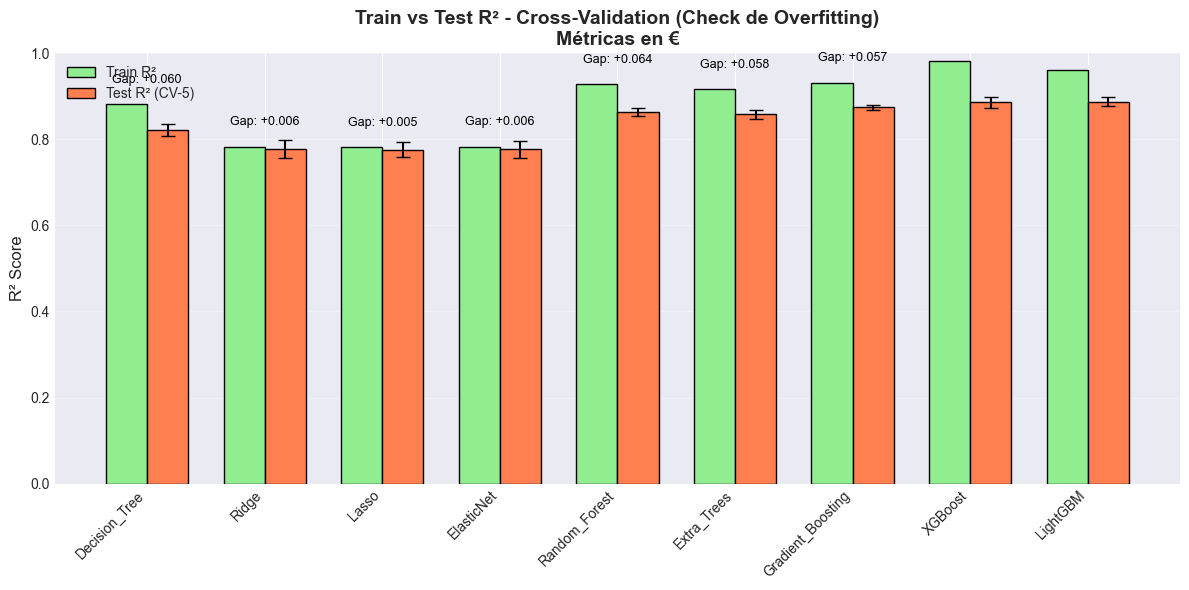


INFO: Si 'Overfitting Gap' > 0.10, el modelo está sobreajustando al conjunto de train


In [18]:
# Cross-Validation Manual con métricas
print("-"*80)
print("CROSS-VALIDATION MANUAL - Train/Test Metrics por Fold")
print("-"*80)

# Usar los mejores modelos del tuning
cv_models = {}
cv_scalers = {}  # Guardar scalers para modelos lineales

# Añadir Decision Tree
cv_models['Decision_Tree'] = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=30,
    min_samples_leaf=15,
    random_state=42
)
cv_scalers['Decision_Tree'] = None

# Añadir mejores modelos de tuning
for model_name in models_to_tune:
    if model_name in tuning_results:
        cv_models[model_name] = tuning_results[model_name]['best_model']
        cv_scalers[model_name] = tuning_results[model_name].get('scaler', None)

# Definición CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_detailed_results = {}

for model_name, model in cv_models.items():
    print(f"\n{'-'*80}")
    print(f"Evaluando {model_name} con CV-5")
    print(f"{'-'*80}")
    
    scaler_template = cv_scalers[model_name]
    needs_scaling = scaler_template is not None
    
    train_r2, train_rmse, train_mae, train_mape = [], [], [], []
    test_r2, test_rmse, test_mae, test_mape = [], [], [], []
    
    fold_num = 1
    
    for train_idx, test_idx in cv.split(X, y):
        X_train_cv, X_test_cv = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]
        
        # Para modelos lineales, escalar datos antes de entrenar
        if needs_scaling:
            from sklearn.preprocessing import RobustScaler
            fold_scaler = RobustScaler()
            X_train_cv_scaled = fold_scaler.fit_transform(X_train_cv)
            X_test_cv_scaled = fold_scaler.transform(X_test_cv)
        else:
            X_train_cv_scaled = X_train_cv
            X_test_cv_scaled = X_test_cv
        
        # Entrenar
        model.fit(X_train_cv_scaled, y_train_cv)
        
        # Predicciones
        y_pred_train = model.predict(X_train_cv_scaled)
        y_pred_test = model.predict(X_test_cv_scaled)
        
        # Convertir a € para métricas interpretables (si está en escala log)
        y_train_cv_eur = inverse_transform(y_train_cv)
        y_test_cv_eur = inverse_transform(y_test_cv)
        y_pred_train_eur = inverse_transform(y_pred_train)
        y_pred_test_eur = inverse_transform(y_pred_test)
        
        # Métricas - Train (en €)
        train_r2.append(r2_score(y_train_cv_eur, y_pred_train_eur))
        train_rmse.append(np.sqrt(mean_squared_error(y_train_cv_eur, y_pred_train_eur)))
        train_mae.append(mean_absolute_error(y_train_cv_eur, y_pred_train_eur))
        train_mape.append(mean_absolute_percentage_error(y_train_cv_eur, y_pred_train_eur))
        
        # Métricas - Test (en €)
        test_r2.append(r2_score(y_test_cv_eur, y_pred_test_eur))
        test_rmse.append(np.sqrt(mean_squared_error(y_test_cv_eur, y_pred_test_eur)))
        test_mae.append(mean_absolute_error(y_test_cv_eur, y_pred_test_eur))
        test_mape.append(mean_absolute_percentage_error(y_test_cv_eur, y_pred_test_eur))
        
        print(f"- Fold {fold_num}: R²(Train)={train_r2[-1]:.4f}, R²(Test)={test_r2[-1]:.4f}, Diff={train_r2[-1]-test_r2[-1]:+.4f}")
        fold_num += 1
    
    # Calcular means and stds
    cv_detailed_results[model_name] = {
        'train_r2_mean': np.mean(train_r2),
        'train_r2_std': np.std(train_r2),
        'test_r2_mean': np.mean(test_r2),
        'test_r2_std': np.std(test_r2),
        'train_rmse_mean': np.mean(train_rmse),
        'test_rmse_mean': np.mean(test_rmse),
        'train_mae_mean': np.mean(train_mae),
        'test_mae_mean': np.mean(test_mae),
        'train_mape_mean': np.mean(train_mape),
        'test_mape_mean': np.mean(test_mape),
        'overfitting_gap': np.mean(train_r2) - np.mean(test_r2)
    }
    
    print(f"\nRESUMEN {model_name} (métricas en €):")
    print(f"- Train R²: {np.mean(train_r2):.4f} (±{np.std(train_r2):.4f})")
    print(f"- Test R²: {np.mean(test_r2):.4f} (±{np.std(test_r2):.4f})")
    print(f"- Overfitting Gap: {cv_detailed_results[model_name]['overfitting_gap']:+.4f}")
    print(f"- Test RMSE: €{np.mean(test_rmse):,.0f}")
    print(f"- Test MAE: €{np.mean(test_mae):,.0f}")
    print(f"- Test MAPE: {np.mean(test_mape)*100:.2f}%")

cv_summary = pd.DataFrame(cv_detailed_results).T
cv_summary = cv_summary.sort_values('test_r2_mean', ascending=False)

print("\n" + "-"*80)
print("RESUMEN CROSS-VALIDATION (métricas en €)")
print("-"*80)
print(cv_summary[['train_r2_mean', 'test_r2_mean', 'overfitting_gap', 'test_rmse_mean', 'test_mape_mean']].round(4))

# Visualización Train vs Test
fig, ax = plt.subplots(figsize=(12, 6))
models_list = list(cv_detailed_results.keys())
x = np.arange(len(models_list))
width = 0.35

train_means = [cv_detailed_results[m]['train_r2_mean'] for m in models_list]
test_means = [cv_detailed_results[m]['test_r2_mean'] for m in models_list]
test_stds = [cv_detailed_results[m]['test_r2_std'] for m in models_list]

bars1 = ax.bar(x - width/2, train_means, width, label='Train R²', color='lightgreen', edgecolor='black')
bars2 = ax.bar(x + width/2, test_means, width, yerr=test_stds, capsize=5,
                label='Test R² (CV-5)', color='coral', edgecolor='black')

ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Train vs Test R² - Cross-Validation (Check de Overfitting)\nMétricas en €', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Add overfitting gap annotations
for i, model in enumerate(models_list):
    gap = cv_detailed_results[model]['overfitting_gap']
    ax.annotate(f'Gap: {gap:+.3f}',
                xy=(i, max(train_means[i], test_means[i]) + 0.05),
                ha='center', fontsize=9, color='red' if gap > 0.1 else 'black')

plt.tight_layout()
plt.show()

print(f"\nINFO: Si 'Overfitting Gap' > 0.10, el modelo está sobreajustando al conjunto de train")

### 6.2 Evaluación Completa en Test Set

Aplicar los mejores hiperparámetros encontrados al conjunto de test para obtener métricas definitivas.

In [19]:
# Evaluación completa con métricas en € (interpretables)
# IMPORTANTE: si LOG_TRANSFORM_TARGET=1, las predicciones están en log → Convertir a €
test_results = {}

# Convertir y_train e y_test a €
y_train_eur = inverse_transform(y_train)
y_test_eur = inverse_transform(y_test)

# Añadir Decision Tree a los resultados
test_results['Decision_Tree'] = {
    'r2_train': r2_train_dt,
    'rmse_train': rmse_train_dt,
    'mae_train': mae_train_dt,
    'mape_train': mape_train_dt,
    'me_train': me_train_dt,
    'mpe_train': mpe_train_dt,
    'r2': r2_test_dt,
    'rmse': rmse_test_dt,
    'mae': mae_test_dt,
    'mape': mape_test_dt,
    'me': me_test_dt,
    'mpe': mpe_test_dt,
    'cv_score': None
}

# Evaluar modelos tuneados
for model_name, result in tuning_results.items():
    model = result['best_model']
    scaler = result.get('scaler', None)

    # Para modelos lineales, usar el scaler antes de predecir
    if scaler is not None:
        X_train_for_pred = scaler.transform(X_train)
        X_test_for_pred = scaler.transform(X_test)
    else:
        X_train_for_pred = X_train
        X_test_for_pred = X_test

    # Predicciones (log si LOG_TRANSFORM_TARGET=1)
    y_pred_train_raw = model.predict(X_train_for_pred)
    y_pred_test_raw = model.predict(X_test_for_pred)
    
    # Convertir a € para métricas interpretables
    y_pred_train = inverse_transform(y_pred_train_raw)
    y_pred_test = inverse_transform(y_pred_test_raw)

    # MÉTRICAS - TRAIN (en €)
    r2_train = r2_score(y_train_eur, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train_eur, y_pred_train))
    mae_train = mean_absolute_error(y_train_eur, y_pred_train)
    mape_train = mean_absolute_percentage_error(y_train_eur, y_pred_train)
    me_train = np.mean(y_pred_train - y_train_eur)
    mpe_train = np.mean((y_pred_train - y_train_eur) / y_train_eur)

    # MÉTRICAS - TEST (en €)
    r2 = r2_score(y_test_eur, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test_eur, y_pred_test))
    mae = mean_absolute_error(y_test_eur, y_pred_test)
    mape = mean_absolute_percentage_error(y_test_eur, y_pred_test)
    me = np.mean(y_pred_test - y_test_eur)
    mpe = np.mean((y_pred_test - y_test_eur) / y_test_eur)

    test_results[model_name] = {
        'r2_train': r2_train,
        'rmse_train': rmse_train,
        'mae_train': mae_train,
        'mape_train': mape_train,
        'me_train': me_train,
        'mpe_train': mpe_train,
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'me': me,
        'mpe': mpe,
        'cv_score': result['best_score']
    }
    print(f"\n{model_name} (métricas en €):")
    print(f"- R² (Train): {r2_train:.4f}")
    print(f"- R² (CV, escala entrenamiento): {result['best_score']:.4f}")
    print(f"- R² (Test): {r2:.4f}")
    print(f"- RMSE (Train): €{rmse_train:,.0f}")
    print(f"- RMSE (Test): €{rmse:,.0f}")
    print(f"- MAE (Train): €{mae_train:,.0f}")
    print(f"- MAE (Test): €{mae:,.0f}")
    print(f"- MAPE (Train): {mape_train*100:.2f}%")
    print(f"- MAPE (Test): {mape*100:.2f}%")
    print(f"- ME (Train): €{me_train:,.0f} {'(sobreestima)' if me_train > 0 else '(subestima)'}")
    print(f"- ME (Test): €{me:,.0f} {'(sobreestima)' if me > 0 else '(subestima)'}")
    print(f"- MPE (Train): {mpe_train*100:.2f}%")
    print(f"- MPE (Test): {mpe*100:.2f}%")
    print(f"- Overfitting Gap (R²): {r2_train - r2:+.4f}")

results_df = pd.DataFrame(test_results).T
results_df = results_df.sort_values('r2', ascending=False)

print("\n" + "-"*80)
print("RESUMEN DE RESULTADOS DE TODOS LOS MODELOS (en €)")
print("-"*80)
print(results_df.round(4))


Ridge (métricas en €):
- R² (Train): 0.7785
- R² (CV, escala entrenamiento): 0.8047
- R² (Test): 0.7895
- RMSE (Train): €104,690
- RMSE (Test): €109,310
- MAE (Train): €73,116
- MAE (Test): €73,929
- MAPE (Train): 11.91%
- MAPE (Test): 11.42%
- ME (Train): €-9,180 (subestima)
- ME (Test): €-17,398 (subestima)
- MPE (Train): 0.67%
- MPE (Test): -0.26%
- Overfitting Gap (R²): -0.0110

Lasso (métricas en €):
- R² (Train): 0.7770
- R² (CV, escala entrenamiento): 0.8031
- R² (Test): 0.7857
- RMSE (Train): €105,048
- RMSE (Test): €110,290
- MAE (Train): €73,672
- MAE (Test): €74,670
- MAPE (Train): 11.99%
- MAPE (Test): 11.55%
- ME (Train): €-9,901 (subestima)
- ME (Test): €-18,172 (subestima)
- MPE (Train): 0.67%
- MPE (Test): -0.27%
- Overfitting Gap (R²): -0.0087

ElasticNet (métricas en €):
- R² (Train): 0.7787
- R² (CV, escala entrenamiento): 0.8048
- R² (Test): 0.7892
- RMSE (Train): €104,641
- RMSE (Test): €109,380
- MAE (Train): €73,133
- MAE (Test): €73,980
- MAPE (Train): 11.91%
-

---

## 7. Visualizaciones

### 7.1 Comparación de Métricas entre Modelos

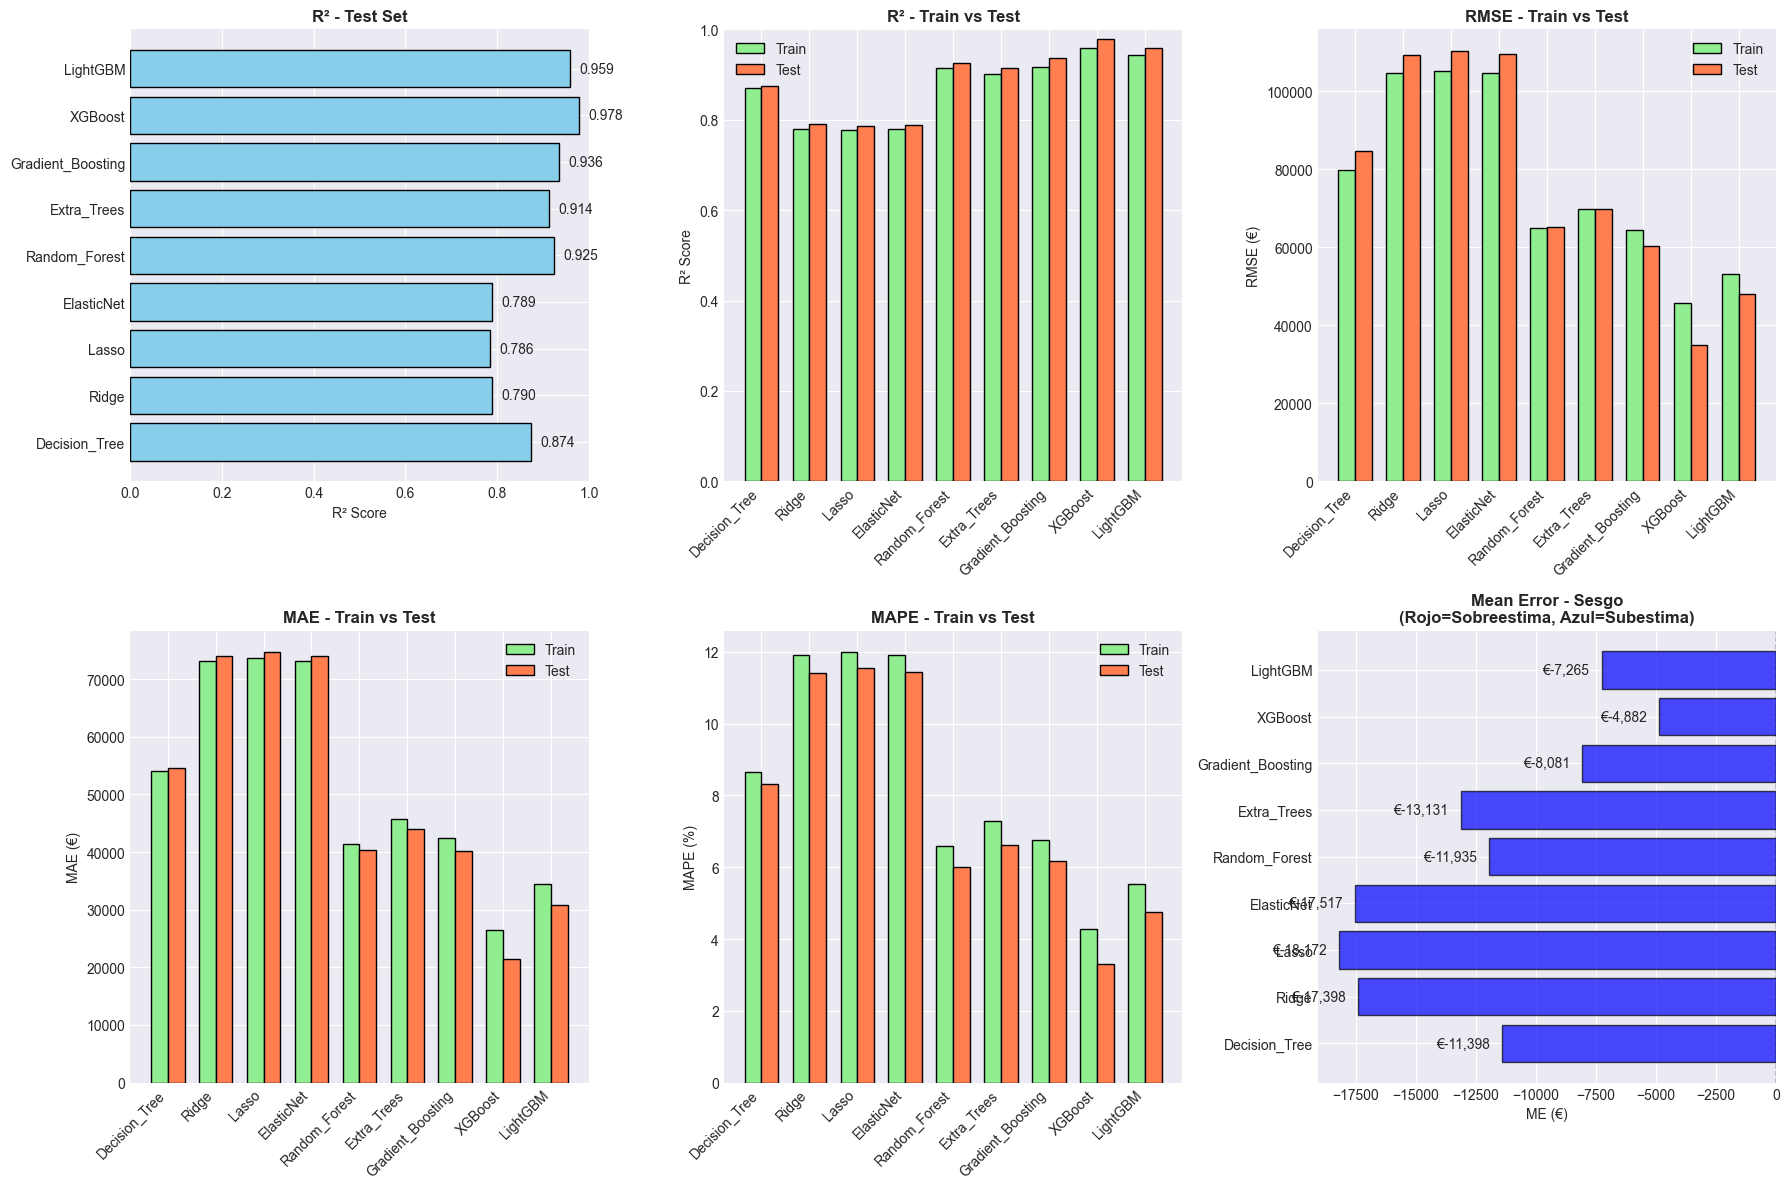

In [20]:
# Comparación de métricas entre modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
models = list(test_results.keys())
metrics_data = {
    'R² (Test)': [test_results[m]['r2'] for m in models],
    'R² (Train)': [test_results[m]['r2_train'] for m in models],
    'RMSE (Test)': [test_results[m]['rmse'] for m in models],
    'RMSE (Train)': [test_results[m].get('rmse_train', test_results[m]['rmse']) for m in models],
    'MAE (Test)': [test_results[m]['mae'] for m in models],
    'MAE (Train)': [test_results[m].get('mae_train', test_results[m]['mae']) for m in models],
    'MAPE (Test)': [test_results[m]['mape']*100 for m in models],
    'MAPE (Train)': [test_results[m].get('mape_train', test_results[m]['mape'])*100 for m in models],
    'ME (Sesgo)': [test_results[m]['me'] for m in models]
}

# R² Test
axes[0, 0].barh(models, metrics_data['R² (Test)'], color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_title('R² - Test Set', fontweight='bold')
axes[0, 0].set_xlim(0, 1)
for i, v in enumerate(metrics_data['R² (Test)']):
    axes[0, 0].text(v + 0.02, i, f"{v:.3f}", va='center')

# R² Train vs Test
x = np.arange(len(models))
width = 0.35
axes[0, 1].bar(x - width/2, metrics_data['R² (Train)'], width, label='Train', color='lightgreen', edgecolor='black')
axes[0, 1].bar(x + width/2, metrics_data['R² (Test)'], width, label='Test', color='coral', edgecolor='black')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_title('R² - Train vs Test', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].set_ylim(0, 1)

# RMSE Train vs Test
axes[0, 2].bar(x - width/2, metrics_data['RMSE (Train)'], width, label='Train', color='lightgreen', edgecolor='black')
axes[0, 2].bar(x + width/2, metrics_data['RMSE (Test)'], width, label='Test', color='coral', edgecolor='black')
axes[0, 2].set_ylabel('RMSE (€)')
axes[0, 2].set_title('RMSE - Train vs Test', fontweight='bold')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(models, rotation=45, ha='right')
axes[0, 2].legend()

# MAE Train vs Test
axes[1, 0].bar(x - width/2, metrics_data['MAE (Train)'], width, label='Train', color='lightgreen', edgecolor='black')
axes[1, 0].bar(x + width/2, metrics_data['MAE (Test)'], width, label='Test', color='coral', edgecolor='black')
axes[1, 0].set_ylabel('MAE (€)')
axes[1, 0].set_title('MAE - Train vs Test', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
axes[1, 0].legend()

# MAPE Train vs Test
axes[1, 1].bar(x - width/2, metrics_data['MAPE (Train)'], width, label='Train', color='lightgreen', edgecolor='black')
axes[1, 1].bar(x + width/2, metrics_data['MAPE (Test)'], width, label='Test', color='coral', edgecolor='black')
axes[1, 1].set_ylabel('MAPE (%)')
axes[1, 1].set_title('MAPE - Train vs Test', fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=45, ha='right')
axes[1, 1].legend()

# ME (Mean Error - Sesgo)
colors_me = ['red' if me > 0 else 'blue' for me in metrics_data['ME (Sesgo)']]
axes[1, 2].barh(models, metrics_data['ME (Sesgo)'], color=colors_me, alpha=0.7, edgecolor='black')
axes[1, 2].set_xlabel('ME (€)')
axes[1, 2].set_title('Mean Error - Sesgo\n(Rojo=Sobreestima, Azul=Subestima)', fontweight='bold')
axes[1, 2].axvline(x=0, color='black', linestyle='--', linewidth=1)
for i, v in enumerate(metrics_data['ME (Sesgo)']):
    axes[1, 2].text(v + 500 if v > 0 else v - 500, i, f"€{v:,.0f}", va='center',
                    ha='left' if v > 0 else 'right')

plt.tight_layout()
plt.show()

### 7.2 Análisis de Overfitting Gap (Train vs Test Gap)


----------------------------------------------------------------------------------------------------
ANÁLISIS DE OVERFITTING - Train vs Test Gap
----------------------------------------------------------------------------------------------------

Interpretación:
- R²_Gap positivo: Train mejor que Test (Overfitting)
- RMSE/MAE/MAPE_Gap positivo: Test peor que Train


            Model    R²_Gap      RMSE_Gap      MAE_Gap  MAPE_Gap
    Decision_Tree -0.002899   4706.917580   439.219773 -0.003575
            Lasso -0.008727   5242.698210   998.680318 -0.004377
    Random_Forest -0.010514    178.928860 -1051.306294 -0.005926
       ElasticNet -0.010526   4739.050631   846.529492 -0.004826
            Ridge -0.011005   4619.398834   812.170981 -0.004867
      Extra_Trees -0.012783    -49.765059 -1754.130111 -0.006678
         LightGBM -0.016203  -5000.829197 -3702.716817 -0.007874
Gradient_Boosting -0.019362  -3938.419563 -2186.212273 -0.006041
          XGBoost -0.020766 -10771.160205 -50

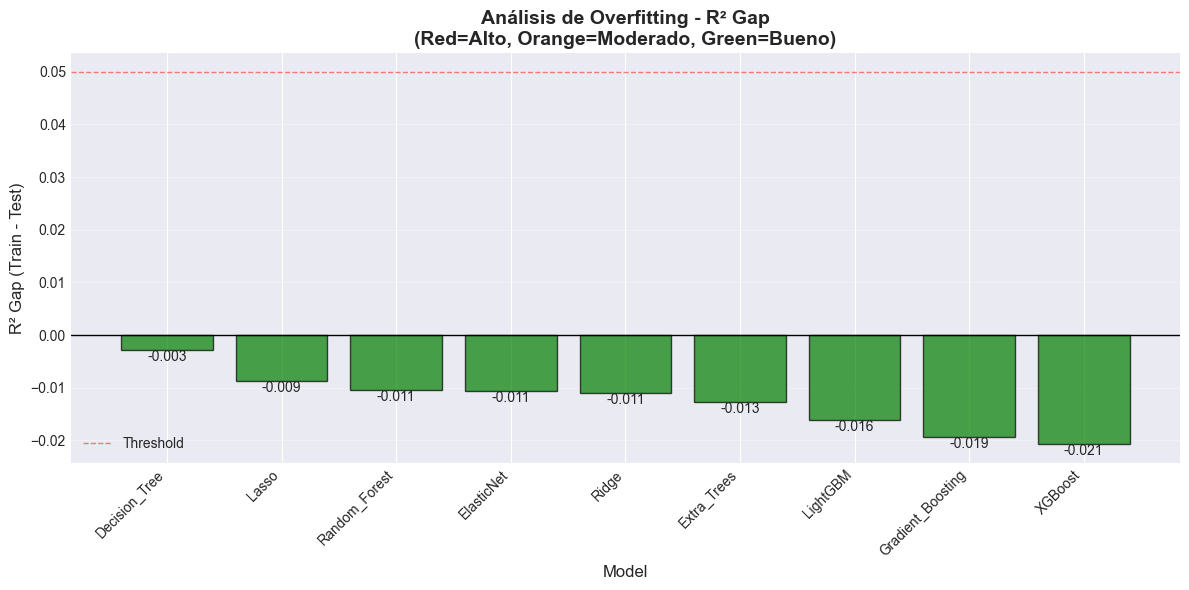

In [21]:
# Análisis de Overfitting (Train vs Test Gap)
print("\n" + "-"*100)
print("ANÁLISIS DE OVERFITTING - Train vs Test Gap")
print("-"*100)

overfitting_df = pd.DataFrame()
overfitting_df['Model'] = models

# Calcular gaps (Train - Test)
for m in models:
    train_r2 = test_results[m]['r2_train']
    test_r2 = test_results[m]['r2']
    train_rmse = test_results[m].get('rmse_train', 0)
    test_rmse = test_results[m]['rmse']
    train_mae = test_results[m].get('mae_train', 0)
    test_mae = test_results[m]['mae']
    train_mape = test_results[m].get('mape_train', 0)
    test_mape = test_results[m]['mape']
    
    # R² Gap (Train mejor = positivo = overfitting)
    overfitting_df.loc[overfitting_df['Model'] == m, 'R²_Gap'] = train_r2 - test_r2
    # RMSE Gap (Test peor = positivo)
    overfitting_df.loc[overfitting_df['Model'] == m, 'RMSE_Gap'] = test_rmse - train_rmse
    # MAE Gap (Test peor = positivo)
    overfitting_df.loc[overfitting_df['Model'] == m, 'MAE_Gap'] = test_mae - train_mae
    # MAPE Gap (Test peor = positivo)
    overfitting_df.loc[overfitting_df['Model'] == m, 'MAPE_Gap'] = test_mape - train_mape

overfitting_df = overfitting_df.sort_values('R²_Gap', ascending=False)

print("\nInterpretación:")
print("- R²_Gap positivo: Train mejor que Test (Overfitting)")
print("- RMSE/MAE/MAPE_Gap positivo: Test peor que Train")
print("\n")
print(overfitting_df.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(overfitting_df))
colors = [
    'red' if gap > 0.05 else 'orange' if gap > 0.02 else 'green'
    for gap in overfitting_df['R²_Gap']
]
bars = ax.bar(x_pos, overfitting_df['R²_Gap'], color=colors, edgecolor='black', alpha=0.7)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('R² Gap (Train - Test)', fontsize=12)
ax.set_title(
    'Análisis de Overfitting - R² Gap\n(Red=Alto, Orange=Moderado, Green=Bueno)',
    fontsize=14, fontweight='bold'
)
ax.set_xticks(x_pos)
ax.set_xticklabels(overfitting_df['Model'], rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Threshold')
ax.grid(axis='y', alpha=0.3)
ax.legend()

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., height,
        f'{height:+.3f}',
        ha='center', va='bottom' if height > 0 else 'top', fontsize=10
    )

plt.tight_layout()
plt.show()

---

## 8. Comparación Final: CV-5 KFold y Selección del Modelo

**Comparación definitiva de todos los modelos tuneados con `cross_validate` (5 folds).**

COMPARACIÓN FINAL: Validación Cruzada CV-5 (métricas en €):

Decision Tree       : Test R² = 0.8215 (±0.0145) | Train R² = 0.8812 | Gap = +0.0597  (en €)
Ridge               : Test R² = 0.7767 (±0.0206) | Train R² = 0.7828 | Gap = +0.0061  (en €)
Lasso               : Test R² = 0.7755 (±0.0172) | Train R² = 0.7810 | Gap = +0.0055  (en €)
ElasticNet          : Test R² = 0.7768 (±0.0197) | Train R² = 0.7828 | Gap = +0.0060  (en €)
Random Forest       : Test R² = 0.8638 (±0.0090) | Train R² = 0.9282 | Gap = +0.0644  (en €)
Extra Trees         : Test R² = 0.8583 (±0.0108) | Train R² = 0.9159 | Gap = +0.0576  (en €)
Gradient Boosting   : Test R² = 0.8740 (±0.0063) | Train R² = 0.9311 | Gap = +0.0571  (en €)
XGBoost             : Test R² = 0.8855 (±0.0124) | Train R² = 0.9812 | Gap = +0.0957  (en €)
LightGBM            : Test R² = 0.8867 (±0.0105) | Train R² = 0.9611 | Gap = +0.0744  (en €)
Baseline Mean       : Test R² = -0.0288 (±0.0097) | Train R² = -0.0281 | Gap = +0.0007  (en €)
Baselin

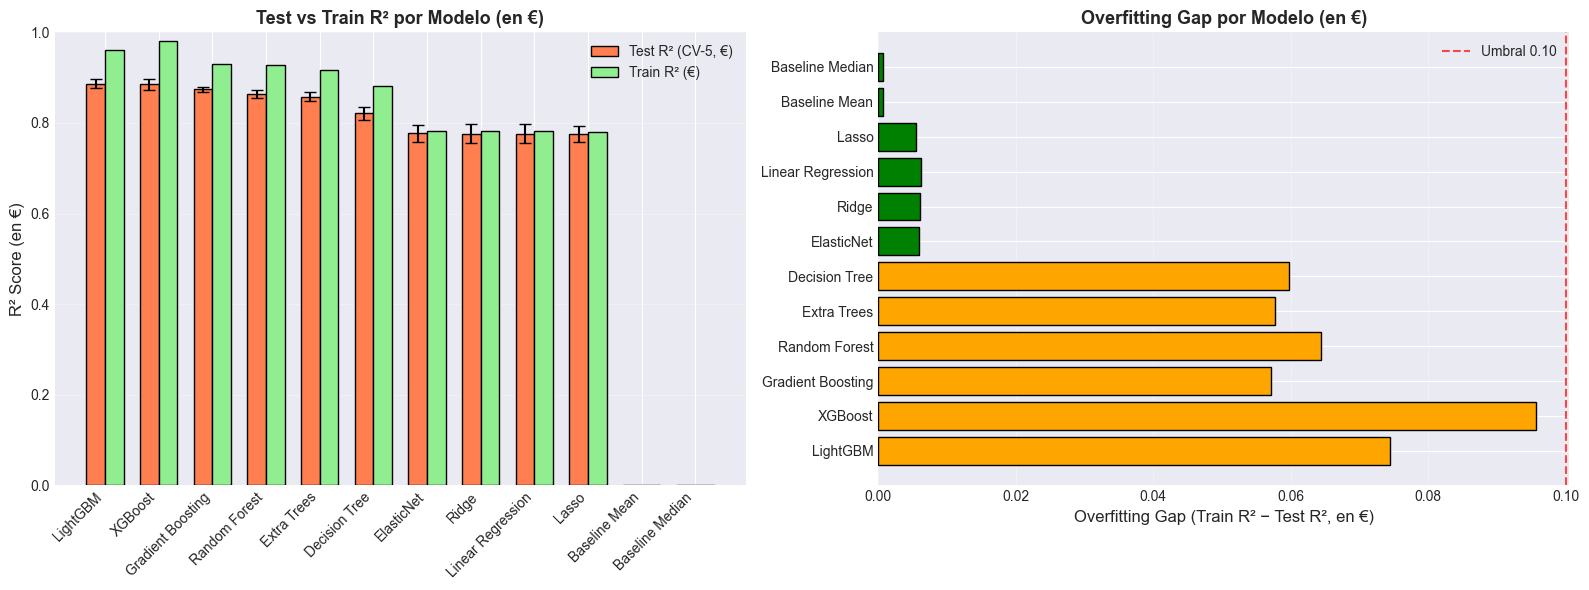


Interpretación: Gap < 0.05 → mínimo overfitting | Gap 0.05-0.15 → aceptable | Gap > 0.15 → overfitting severo

--------------------------------------------------------------------------------
MEJOR MODELO (CV-5, en €): LightGBM (Test R² = 0.8867)
--------------------------------------------------------------------------------


In [22]:
print("COMPARACIÓN FINAL: Validación Cruzada CV-5 (métricas en €):\n")

# Preparar modelos finales con mejores hiperparámetros
final_models_cv = {
    'Decision Tree': dt_model
}
final_scalers_cv = {
    'Decision Tree': None
}

# Añadir modelos tuneados
for model_name in models_to_tune:
    final_models_cv[model_name.replace('_', ' ')] = tuning_results[model_name]['best_model']
    final_scalers_cv[model_name.replace('_', ' ')] = tuning_results[model_name].get('scaler', None)

# Añadir baselines y Linear Regression
from sklearn.dummy import DummyRegressor
final_models_cv['Baseline Mean']   = DummyRegressor(strategy='mean')
final_models_cv['Baseline Median'] = DummyRegressor(strategy='median')
final_models_cv['Linear Regression'] = LinearRegression()
final_scalers_cv['Baseline Mean'] = None
final_scalers_cv['Baseline Median'] = None
final_scalers_cv['Linear Regression'] = RobustScaler()

cv_results_final = []
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in final_models_cv.items():
    fold_test_r2 = []
    fold_train_r2 = []
    scaler_template = final_scalers_cv.get(model_name, None)
    needs_scaling = scaler_template is not None
    
    from sklearn.base import clone
    
    for train_idx, test_idx in cv.split(X, y):
        X_train_cv, X_test_cv = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]
        
        # Para modelos lineales, escalar datos antes de entrenar
        if needs_scaling:
            fold_scaler = RobustScaler()
            X_train_cv_scaled = fold_scaler.fit_transform(X_train_cv)
            X_test_cv_scaled = fold_scaler.transform(X_test_cv)
        else:
            X_train_cv_scaled = X_train_cv
            X_test_cv_scaled = X_test_cv
        
        # Clonar modelo para evitar estado residual entre folds
        model_fold = clone(model)
        
        # Entrenar y evaluar
        model_fold.fit(X_train_cv_scaled, y_train_cv)
        y_pred_test_raw = model_fold.predict(X_test_cv_scaled)
        y_pred_train_raw = model_fold.predict(X_train_cv_scaled)
        
        # Convertir a € para métricas interpretables
        y_train_cv_eur = inverse_transform(y_train_cv)
        y_test_cv_eur = inverse_transform(y_test_cv)
        y_pred_test_eur = inverse_transform(y_pred_test_raw)
        y_pred_train_eur = inverse_transform(y_pred_train_raw)
        
        fold_test_r2.append(r2_score(y_test_cv_eur, y_pred_test_eur))
        fold_train_r2.append(r2_score(y_train_cv_eur, y_pred_train_eur))
    
    r2_test_mean = np.mean(fold_test_r2)
    r2_test_std = np.std(fold_test_r2)
    r2_train_mean = np.mean(fold_train_r2)
    overfitting_gap = r2_train_mean - r2_test_mean

    cv_results_final.append({
        'Model':           model_name,
        'Test_R2_Mean':    r2_test_mean,
        'Test_R2_Std':     r2_test_std,
        'Train_R2_Mean':   r2_train_mean,
        'Overfitting_Gap': overfitting_gap
    })

    print(f"{model_name:20s}: Test R² = {r2_test_mean:.4f} (±{r2_test_std:.4f}) | "
          f"Train R² = {r2_train_mean:.4f} | Gap = {overfitting_gap:+.4f}  (en €)")

df_cv_final = pd.DataFrame(cv_results_final).sort_values('Test_R2_Mean', ascending=False)

# Visualización: barras dobles Test vs Train R² + gráfico de gaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

models_list = df_cv_final['Model'].tolist()
x = np.arange(len(models_list))
width = 0.35
test_means  = df_cv_final['Test_R2_Mean'].tolist()
test_stds   = df_cv_final['Test_R2_Std'].tolist()
train_means = df_cv_final['Train_R2_Mean'].tolist()
gaps        = df_cv_final['Overfitting_Gap'].tolist()

ax1.bar(x - width/2, test_means, width, yerr=test_stds, capsize=4,
        label='Test R² (CV-5, €)', color='coral', edgecolor='black')
ax1.bar(x + width/2, train_means, width,
        label='Train R² (€)', color='lightgreen', edgecolor='black')
ax1.set_ylabel('R² Score (en €)', fontsize=12)
ax1.set_title('Test vs Train R² por Modelo (en €)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

colors = ['red' if g > 0.15 else 'orange' if g > 0.05 else 'green' for g in gaps]
ax2.barh(models_list, gaps, color=colors, edgecolor='black')
ax2.axvline(x=0.10, color='red', linestyle='--', alpha=0.7, label='Umbral 0.10')
ax2.set_xlabel('Overfitting Gap (Train R² − Test R², en €)', fontsize=12)
ax2.set_title('Overfitting Gap por Modelo (en €)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("\nInterpretación: Gap < 0.05 → mínimo overfitting | Gap 0.05-0.15 → aceptable | Gap > 0.15 → overfitting severo")

best_model_final = df_cv_final.iloc[0]['Model']
best_r2_final    = df_cv_final.iloc[0]['Test_R2_Mean']

print(f"\n{'-'*80}")
print(f"MEJOR MODELO (CV-5, en €): {best_model_final} (Test R² = {best_r2_final:.4f})")
print("-"*80)

---

## 9. Diagnóstico del Modelo Final

### 9.1 Predicciones vs Real


In [23]:
FINAL_MODEL_NAME = best_model_final.replace(' ', '_')
FINAL_MODEL = tuning_results[FINAL_MODEL_NAME]['best_model']
FINAL_SCALER = tuning_results[FINAL_MODEL_NAME].get('scaler', None)

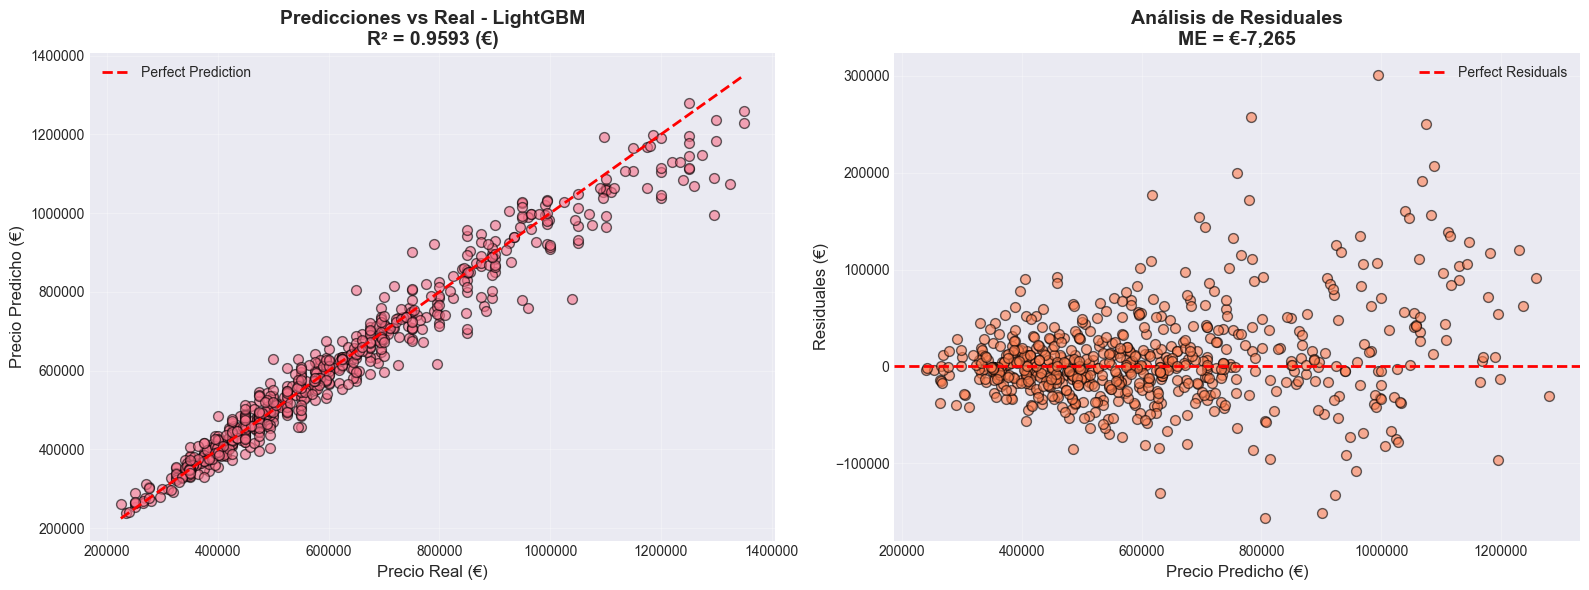


Modelo final: LightGBM
R² (Test, €): 0.9593
RMSE (Test, €): €48,048
MAPE (Test): 4.75%


In [24]:
# Predicciones vs Real del Modelo Final

best_model_name = FINAL_MODEL_NAME
best_model = FINAL_MODEL
best_scaler = FINAL_SCALER

# Si es modelo lineal, usar scaler
if best_scaler is not None:
    X_test_for_pred = best_scaler.transform(X_test)
else:
    X_test_for_pred = X_test

# Predecir y convertir a € (necesario si LOG_TRANSFORM_TARGET=1)
y_pred_best_raw = best_model.predict(X_test_for_pred)
y_pred_best = inverse_transform(y_pred_best_raw)
y_test_eur = inverse_transform(y_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot (en €)
axes[0].scatter(y_test_eur, y_pred_best, alpha=0.6, edgecolors='black', s=50)
axes[0].plot(
    [y_test_eur.min(), y_test_eur.max()], [y_test_eur.min(), y_test_eur.max()],
    'r--', lw=2, label='Perfect Prediction'
)
axes[0].set_xlabel('Precio Real (€)', fontsize=12)
axes[0].set_ylabel('Precio Predicho (€)', fontsize=12)
axes[0].set_title(
    f'Predicciones vs Real - {best_model_name}\nR² = {test_results[best_model_name]["r2"]:.4f} (€)',
    fontsize=14, fontweight='bold'
)
axes[0].ticklabel_format(style='plain', axis='both')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot (en €)
residuals = y_test_eur.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6, edgecolors='black', s=50, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2, label='Perfect Residuals')
axes[1].set_xlabel('Precio Predicho (€)', fontsize=12)
axes[1].set_ylabel('Residuales (€)', fontsize=12)
axes[1].set_title(
    f'Análisis de Residuales\nME = €{test_results[best_model_name]["me"]:,.0f}',
    fontsize=14, fontweight='bold'
)
axes[1].ticklabel_format(style='plain', axis='both')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nModelo final: {best_model_name}")
print(f"R² (Test, €): {test_results[best_model_name]['r2']:.4f}")
print(f"RMSE (Test, €): €{test_results[best_model_name]['rmse']:,.0f}")
print(f"MAPE (Test): {test_results[best_model_name]['mape']*100:.2f}%")

### 9.2 Análisis de Residuos


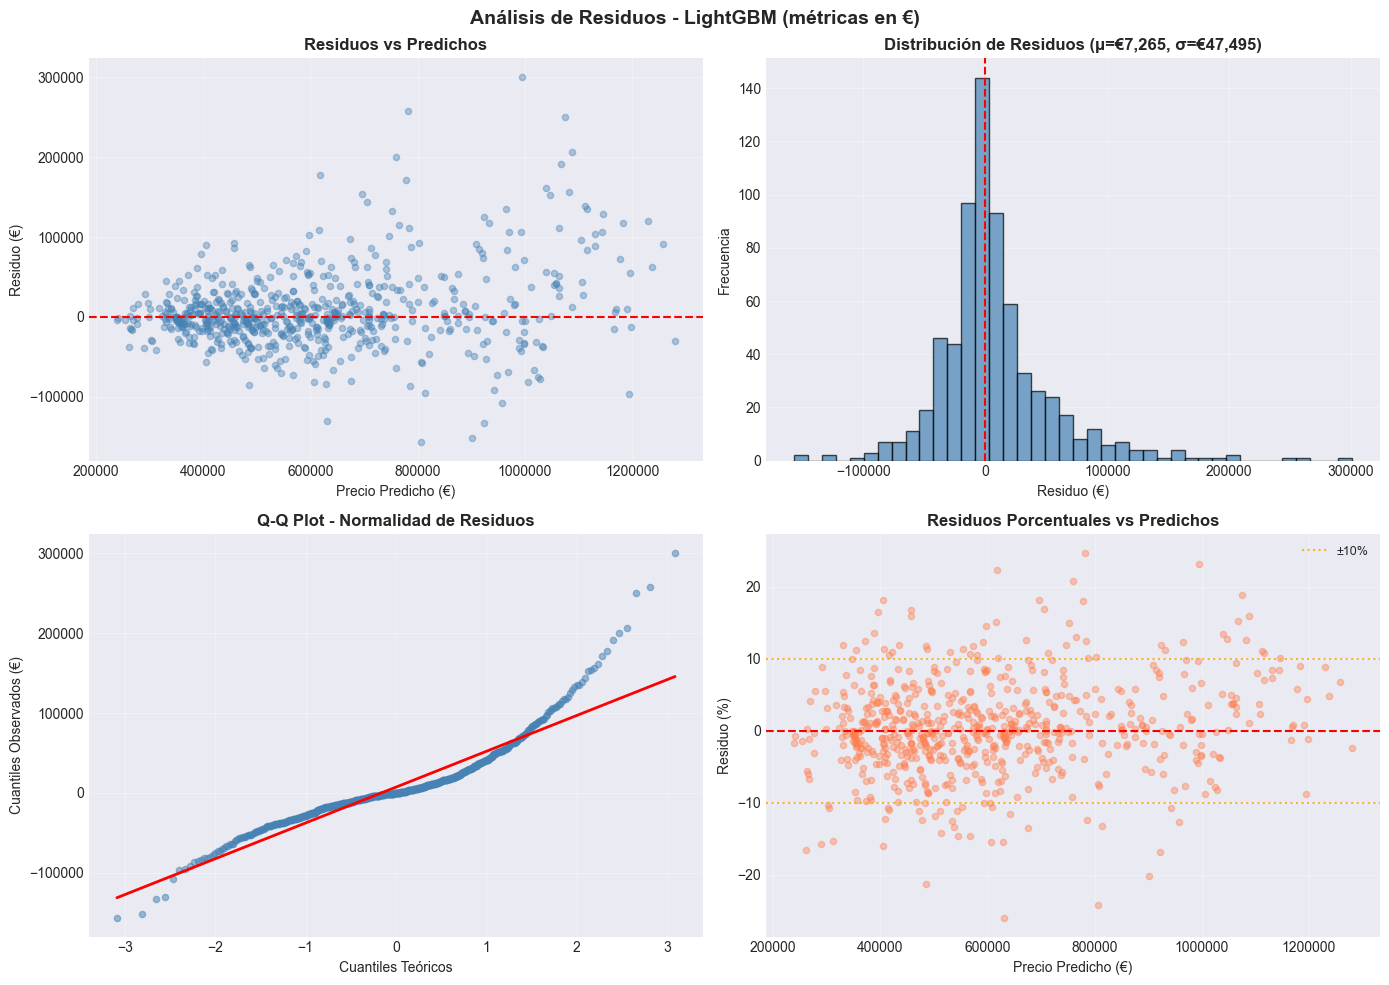


--------------------------------------------------------------------------------
ANÁLISIS DE RESIDUOS - LightGBM (en €)
--------------------------------------------------------------------------------
- Media de residuos: €7,265
- Std de residuos: €47,495
- % predicciones dentro de ±10%: 87.52%
- % predicciones dentro de ±20%: 98.84%


In [25]:
# Análisis de Residuos del Modelo Final (en €)
from scipy import stats as scipy_stats

# Usa FINAL_MODEL establecido tras la comparación CV-5 (sección 8)
_best_res_name = FINAL_MODEL_NAME
_best_res_model = FINAL_MODEL
_res_scaler = FINAL_SCALER

if _res_scaler is not None:
    X_test_for_res = _res_scaler.transform(X_test)
else:
    X_test_for_res = X_test

# Predecir y convertir a € (en log scale los residuos no son interpretables)
y_pred_res_raw = _best_res_model.predict(X_test_for_res)
y_pred_res = inverse_transform(y_pred_res_raw)
y_test_eur = inverse_transform(y_test)

residuals = y_test_eur.values - y_pred_res
res_pct = (residuals / y_test_eur.values) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(y_pred_res, residuals, alpha=0.4, s=20, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0,0].set_xlabel('Precio Predicho (€)'); axes[0,0].set_ylabel('Residuo (€)')
axes[0,0].set_title('Residuos vs Predichos', fontweight='bold')
axes[0,0].ticklabel_format(style='plain', axis='both')
axes[0,0].grid(alpha=0.3)

axes[0,1].hist(residuals, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[0,1].set_xlabel('Residuo (€)'); axes[0,1].set_ylabel('Frecuencia')
axes[0,1].set_title(f'Distribución de Residuos (μ=€{residuals.mean():,.0f}, σ=€{residuals.std():,.0f})', fontweight='bold')
axes[0,1].ticklabel_format(style='plain', axis='x')
axes[0,1].grid(alpha=0.3)

(osm, osr), (slope, intercept, _) = scipy_stats.probplot(residuals, dist='norm')
axes[1,0].scatter(osm, osr, alpha=0.5, s=20, color='steelblue')
axes[1,0].plot(osm, slope * np.array(osm) + intercept, color='red', lw=2)
axes[1,0].set_xlabel('Cuantiles Teóricos'); axes[1,0].set_ylabel('Cuantiles Observados (€)')
axes[1,0].set_title('Q-Q Plot - Normalidad de Residuos', fontweight='bold')
axes[1,0].grid(alpha=0.3)

axes[1,1].scatter(y_pred_res, res_pct, alpha=0.4, s=20, color='coral')
axes[1,1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1,1].axhline(10,  color='orange', linestyle=':', alpha=0.8, label='±10%')
axes[1,1].axhline(-10, color='orange', linestyle=':', alpha=0.8)
axes[1,1].set_xlabel('Precio Predicho (€)'); axes[1,1].set_ylabel('Residuo (%)')
axes[1,1].set_title('Residuos Porcentuales vs Predichos', fontweight='bold')
axes[1,1].ticklabel_format(style='plain', axis='x')
axes[1,1].legend(fontsize=9); axes[1,1].grid(alpha=0.3)

plt.suptitle(f'Análisis de Residuos - {_best_res_name} (métricas en €)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pct_within_10 = (np.abs(res_pct) <= 10).mean() * 100
pct_within_20 = (np.abs(res_pct) <= 20).mean() * 100

print(f"\n{'-'*80}")
print(f"ANÁLISIS DE RESIDUOS - {_best_res_name} (en €)")
print(f"{'-'*80}")
print(f"- Media de residuos: €{residuals.mean():,.0f}")
print(f"- Std de residuos: €{residuals.std():,.0f}")
print(f"- % predicciones dentro de ±10%: {pct_within_10:.2f}%")
print(f"- % predicciones dentro de ±20%: {pct_within_20:.2f}%")

### 9.3 Análisis de Errores por Segmento de Precio

Divide las propiedades en 4 tramos de precio y evalúa las métricas por separado.
Así, se puede detectar si el modelo funciona mejor o peor en ciertos rangos de mercado.

ERRORES POR SEGMENTO DE PRECIO (en €)

          Segmento   N  Precio_Medio_€  MAE_€  MAPE_%      R²
 Económico (<250k)   8          243749  16507     6.8 -4.7832
  Medio (250-400k) 128          355596  13471     3.8  0.6486
Premium (400-600k) 261          496888  23480     4.7  0.6910
      Lujo (>600k) 292          833392  45279     5.1  0.8822


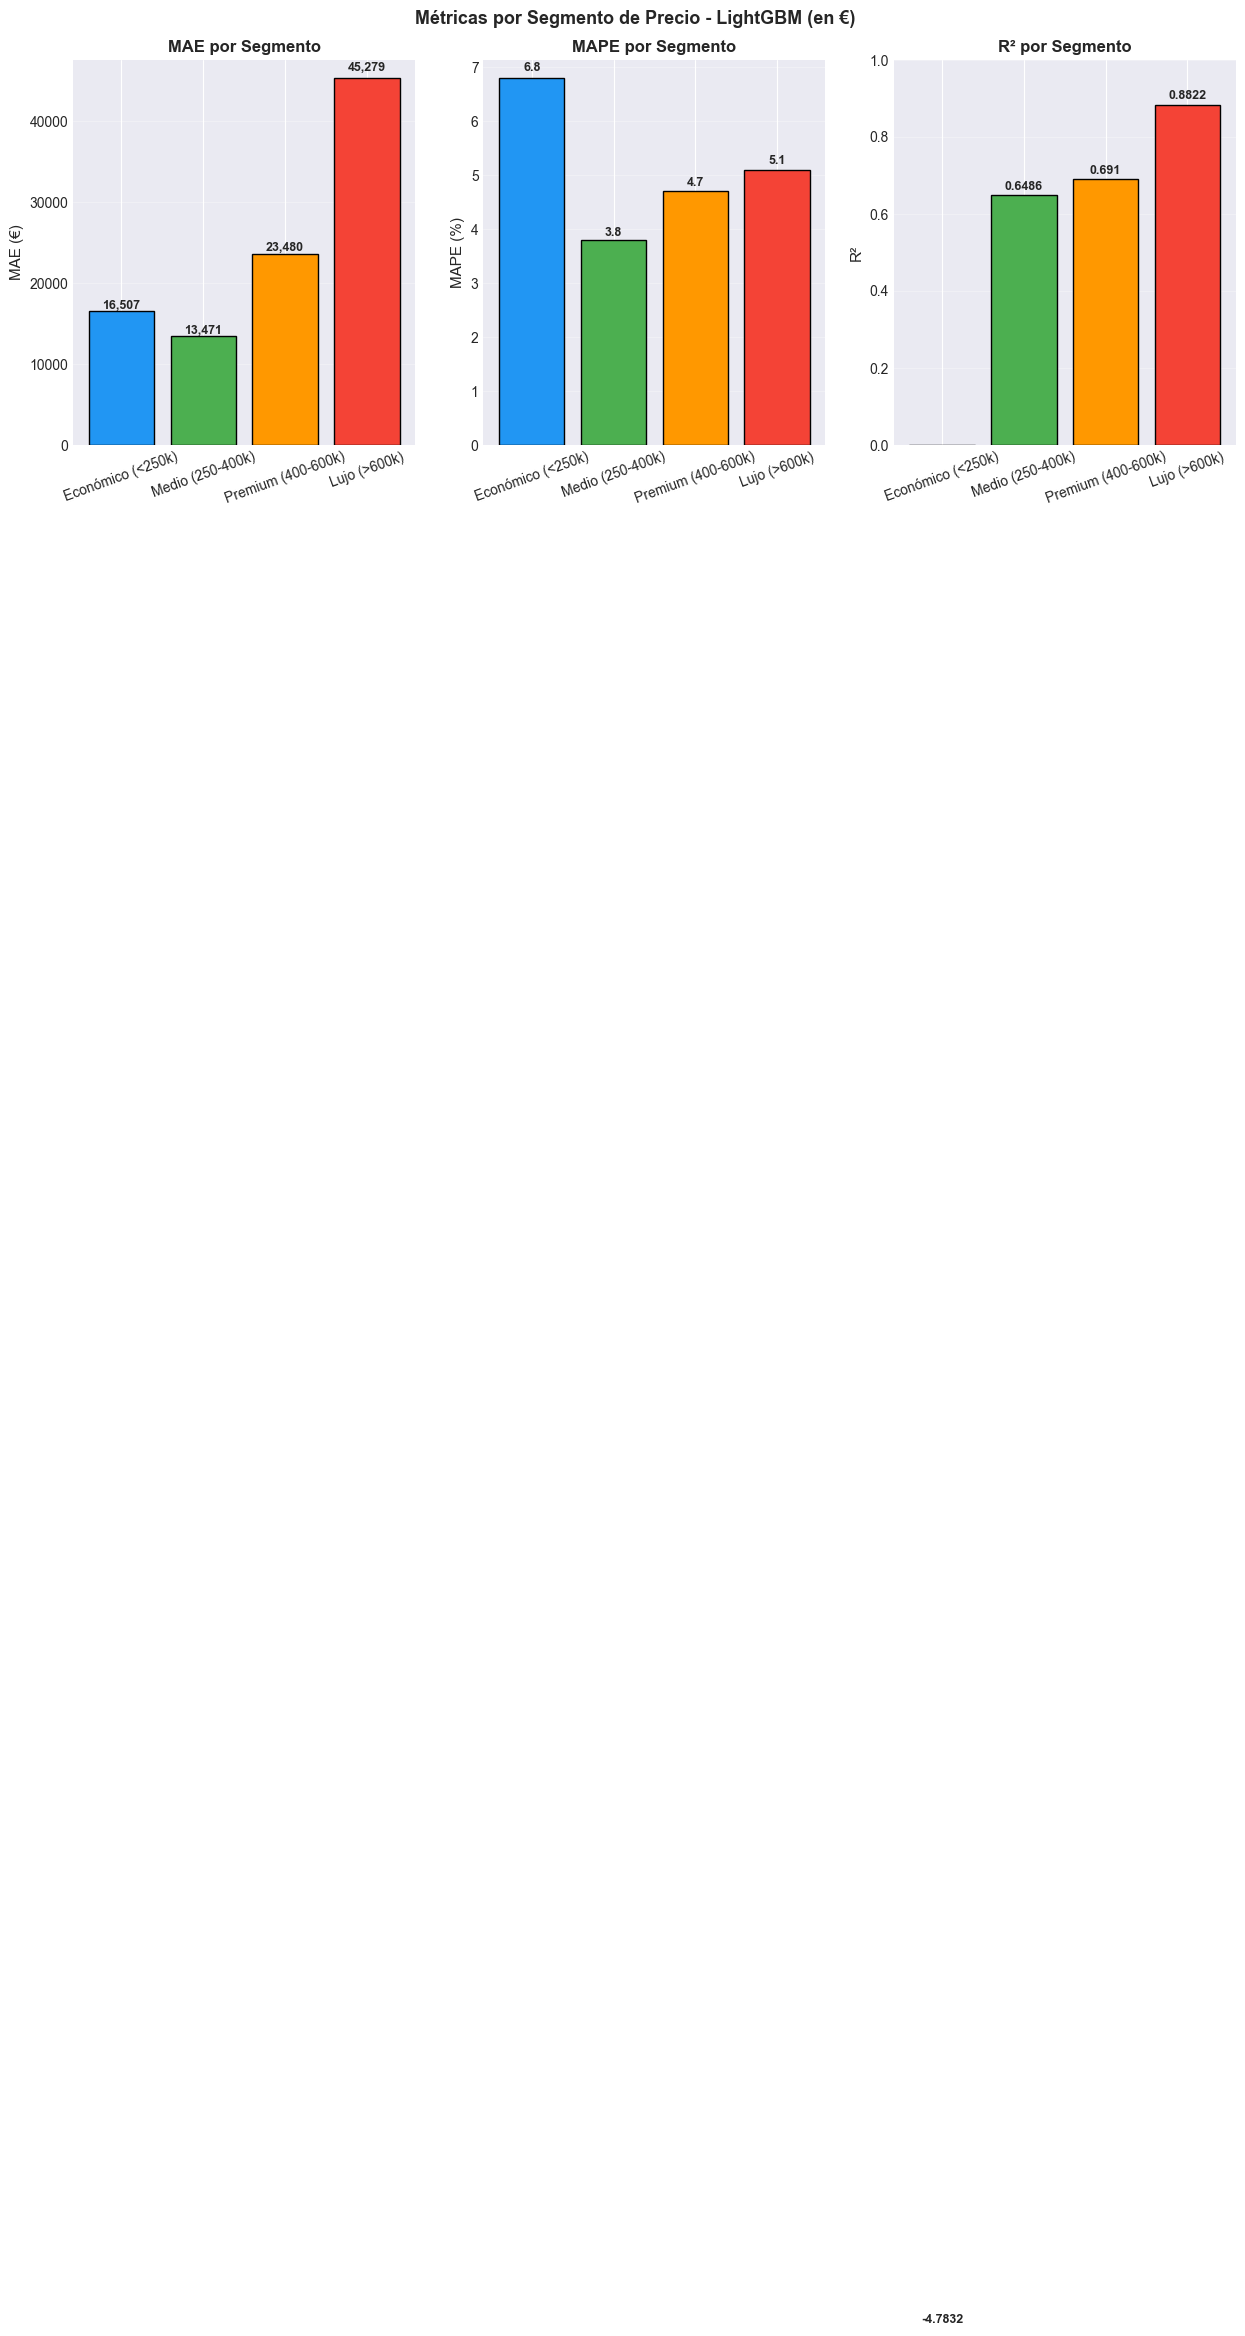

In [26]:
# Análisis de Errores por Segmento de Precio
y_test_eur_arr = inverse_transform(y_test).values if hasattr(inverse_transform(y_test), 'values') else np.asarray(inverse_transform(y_test))

price_segments = pd.cut(
    y_test_eur_arr,
    bins=[0, 250_000, 400_000, 600_000, float('inf')],
    labels=['Económico (<250k)', 'Medio (250-400k)', 'Premium (400-600k)', 'Lujo (>600k)']
)

seg_rows = []
for seg in price_segments.categories:
    mask = price_segments == seg
    if not mask.any():
        continue
    y_t, y_p = y_test_eur_arr[mask], y_pred_res[mask]
    seg_rows.append({
        'Segmento':       str(seg),
        'N':              int(mask.sum()),
        'Precio_Medio_€': int(y_t.mean()),
        'MAE_€':          int(mean_absolute_error(y_t, y_p)),
        'MAPE_%':         round(mean_absolute_percentage_error(y_t, y_p) * 100, 1),
        'R²':             round(r2_score(y_t, y_p), 4),
    })

df_seg = pd.DataFrame(seg_rows)
print("ERRORES POR SEGMENTO DE PRECIO (en €)\n")
print(df_seg.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_seg = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
for ax, (col, ylbl, title) in zip(axes, [
        ('MAE_€',  'MAE (€)',  'MAE por Segmento'),
        ('MAPE_%', 'MAPE (%)','MAPE por Segmento'),
        ('R²',     'R²',      'R² por Segmento')]):
    bars = ax.bar(df_seg['Segmento'], df_seg[col],
                  color=colors_seg[:len(df_seg)], edgecolor='black')
    ax.set_ylabel(ylbl, fontsize=11); ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=20); ax.grid(axis='y', alpha=0.3)
    if col == 'R²': ax.set_ylim(0, 1)
    for bar, v in zip(bars, df_seg[col]):
        label = f'{v:,.0f}' if col == 'MAE_€' else str(v)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                label, ha='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Métricas por Segmento de Precio - {_best_res_name} (en €)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 10. Importancia de Variables y Explicabilidad

Análisis de qué variables predominan sobre el modelo final:
1. Feature importance
2. Anáslisis SHAP

### 10.1 Feature Importance

La *Feature Importance* se calcula directamente desde los modelos tuneados.

FEATURE IMPORTANCE: Comparación entre modelos


Top 15 Características (promedio entre modelos):
   1. living_area                        : 0.945
   2. neighborhood_avg_price             : 0.376
   3. distance_to_center_km              : 0.376
   4. year_built                         : 0.248
   5. area_per_room                      : 0.186
   6. rooms                              : 0.141
   7. area_per_bedroom                   : 0.137
   8. bedrooms                           : 0.125
   9. energy_label_encoded               : 0.107
  10. neighborhood_property_count        : 0.097
  11. neighborhood_avg_area              : 0.071
  12. floor                              : 0.065
  13. property_type_house                : 0.052
  14. bathroom_ratio                     : 0.039
  15. has_garden                         : 0.031


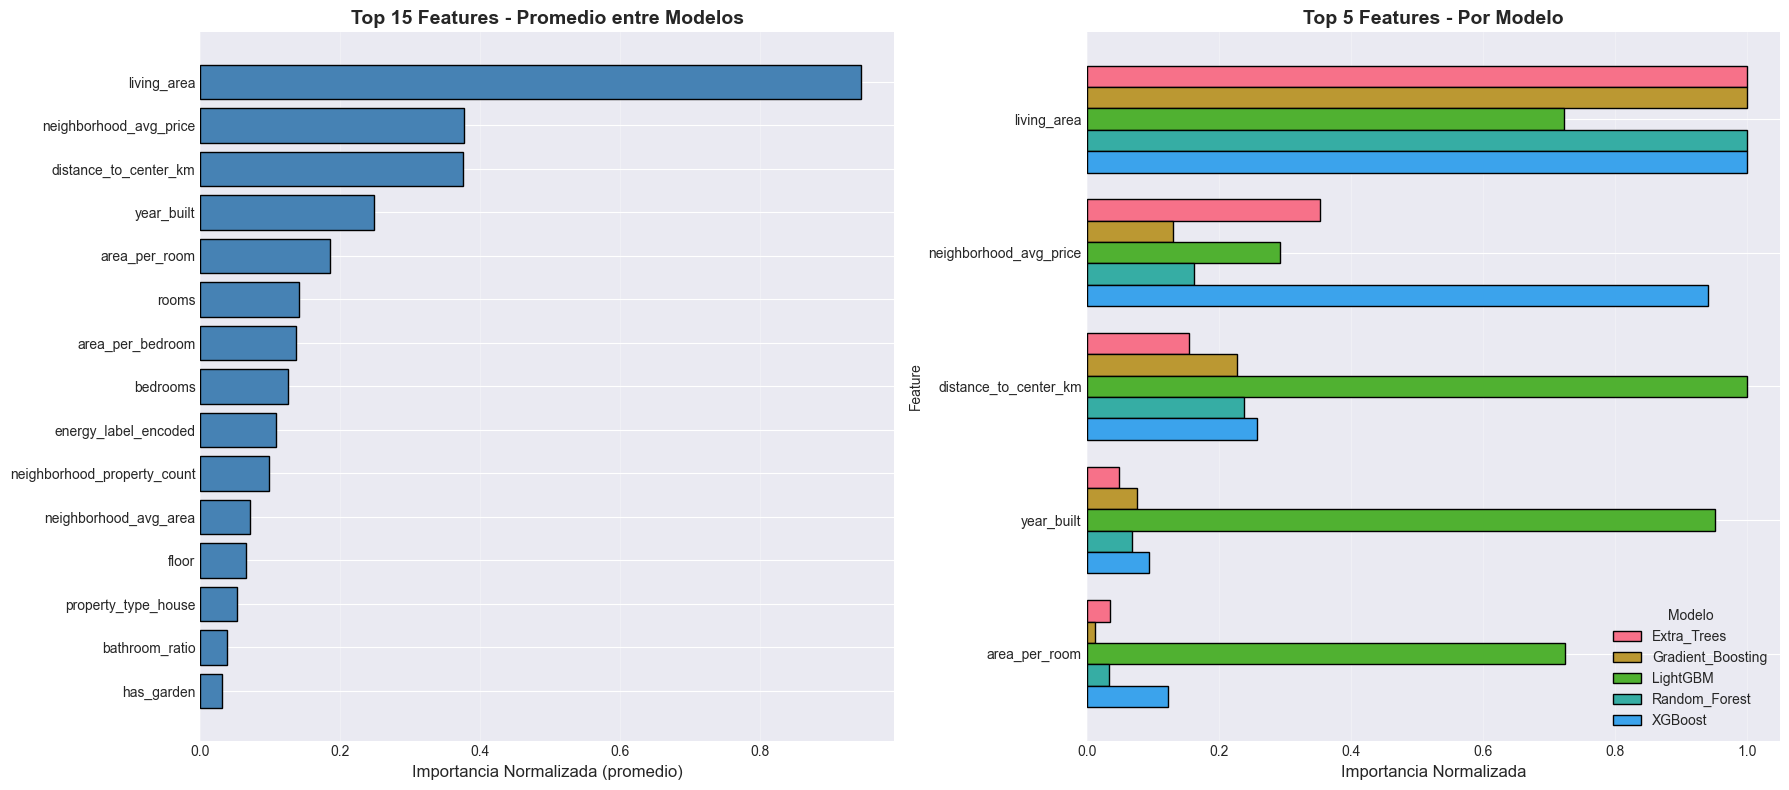

In [27]:
# Feature importance para modelos tree-based
print("FEATURE IMPORTANCE: Comparación entre modelos\n")

importance_dfs = []

for model_name in ['Decision_Tree'] + models_to_tune:
    if model_name == 'Decision_Tree':
        model = dt_model
    else:
        model = tuning_results[model_name]['best_model']

        if hasattr(model, 'feature_importances_'):
            importance = pd.DataFrame({
            'Feature': feature_columns,
            'Importance': model.feature_importances_,
            'Model': model_name
            }).sort_values('Importance', ascending=False)

            importance_dfs.append(importance)

all_importance = pd.concat(importance_dfs)

# Normalizar importancia por modelo
all_importance['Importance_Norm'] = all_importance.groupby('Model')['Importance'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0
)

# Promedio por feature
avg_importance = (
    all_importance.groupby('Feature')['Importance_Norm']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

print(f"\nTop 15 Características (promedio entre modelos):")
for i, (feat, imp) in enumerate(avg_importance.items(), 1):
    print(f"  {i:2d}. {feat:35s}: {imp:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Gráfico 1: Promedio
axes[0].barh(range(len(avg_importance)), avg_importance.values, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(avg_importance)))
axes[0].set_yticklabels(avg_importance.index)
axes[0].set_xlabel('Importancia Normalizada (promedio)', fontsize=12)
axes[0].set_title('Top 15 Features - Promedio entre Modelos', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: Comparación top 5 por modelo
top5_features = avg_importance.head(5).index
comparison_data = all_importance[all_importance['Feature'].isin(top5_features)]
comparison_pivot = comparison_data.pivot(index='Feature', columns='Model', values='Importance_Norm')
comparison_pivot = comparison_pivot.reindex(top5_features)
comparison_pivot.plot(kind='barh', ax=axes[1], width=0.8, edgecolor='black')
axes[1].set_xlabel('Importancia Normalizada', fontsize=12)
axes[1].set_title('Top 5 Features - Por Modelo', fontsize=14, fontweight='bold')
axes[1].legend(title='Modelo', fontsize=10, loc='lower right')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 10.2 SHAP Values

**SHAP (SHapley Additive exPlanations)** descompone cada predicción en contribuciones
individuales de cada feature.

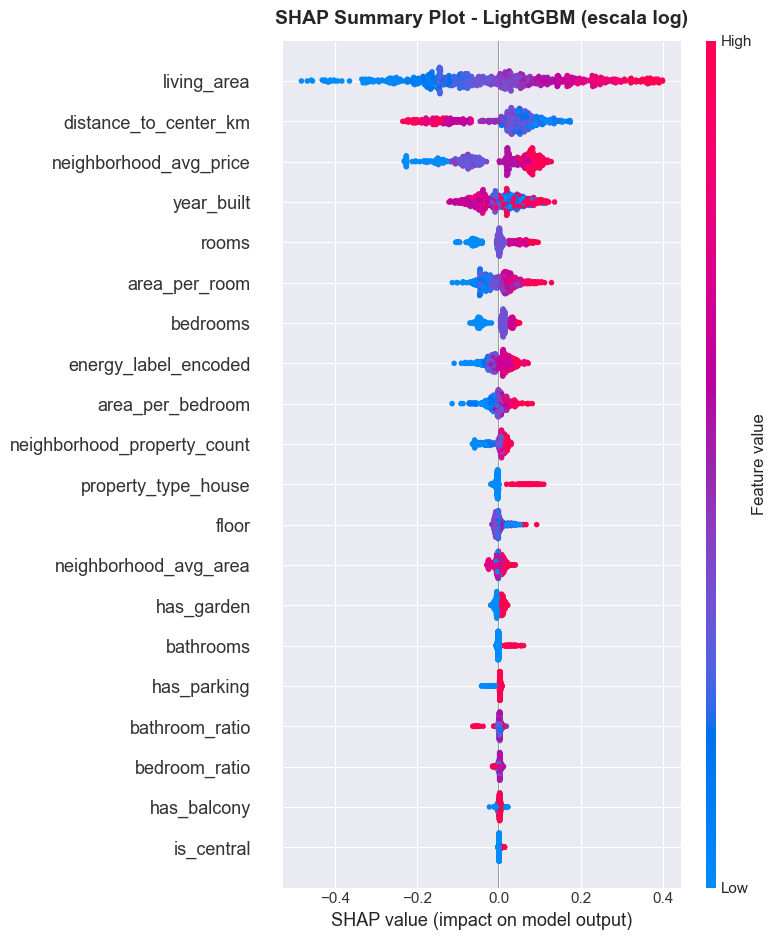

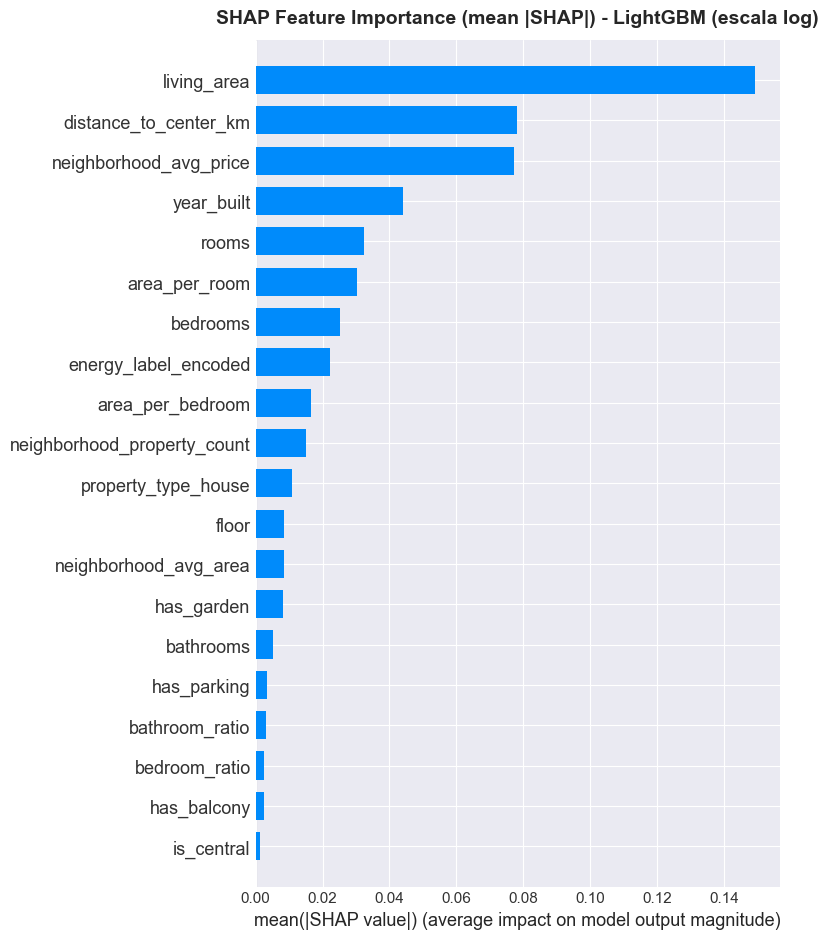

<Figure size 1000x500 with 0 Axes>

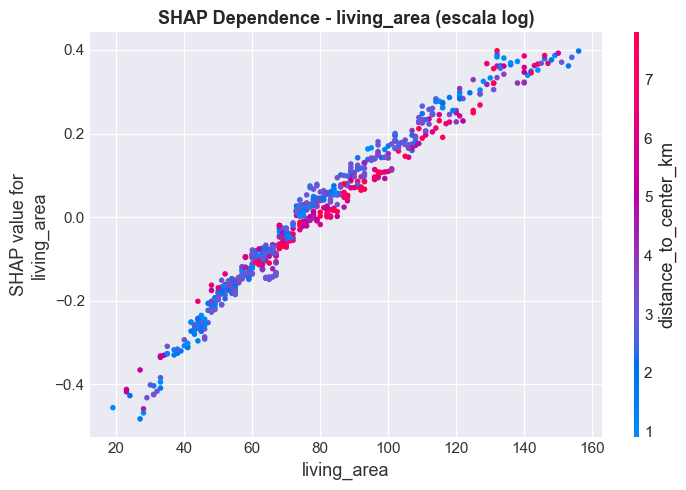


Top 5 features por impacto SHAP medio (escala log):
- 1. living_area:  mean|SHAP| = 0.1493
- 2. distance_to_center_km:  mean|SHAP| = 0.0782
- 3. neighborhood_avg_price:  mean|SHAP| = 0.0774
- 4. year_built:  mean|SHAP| = 0.0441
- 5. rooms:  mean|SHAP| = 0.0323


In [28]:
# SHAP Values: Explicabilidad del Modelo Final

_shap_name = FINAL_MODEL_NAME
_shap_model = FINAL_MODEL
_shap_scaler = FINAL_SCALER

# Preparar datos escalados si es modelo lineal
if _shap_scaler is not None:
    X_test_shap = _shap_scaler.transform(X_test)
    X_train_shap = _shap_scaler.transform(X_train)
else:
    X_test_shap = X_test
    X_train_shap = X_train

# Seleccionar explainer más adecuado
try:
    _explainer = shap.TreeExplainer(_shap_model)
except Exception:
    try:
        _explainer = shap.LinearExplainer(_shap_model, X_train_shap)
    except Exception:
        _bg = shap.sample(X_train_shap, 100)
        _explainer = shap.KernelExplainer(_shap_model.predict, _bg)
        print("WARNING: usando KernelExplainer (lento y aproximado).")

_shap_vals = _explainer.shap_values(X_test_shap)
_feat_names = list(X_test.columns)

# NOTA: si LOG_TRANSFORM_TARGET=1, los SHAP values están en escala log.
if MLConfig.LOG_TRANSFORM_TARGET:
    _scale_note = " (escala log)"
else:
    _scale_note = " (€)"

# Summary beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(_shap_vals, X_test, feature_names=_feat_names, show=False)
plt.title(f'SHAP Summary Plot - {_shap_name}{_scale_note}', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

# Bar (mean |SHAP|)
plt.figure(figsize=(10, 6))
shap.summary_plot(_shap_vals, X_test, feature_names=_feat_names,
                    plot_type='bar', show=False)
plt.title(f'SHAP Feature Importance (mean |SHAP|) - {_shap_name}{_scale_note}',
            fontsize=14, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

# Dependence plot: Feature con mayor impacto
_mean_abs = np.abs(_shap_vals).mean(axis=0)
_top_idx  = int(np.argmax(_mean_abs))
_top_feat = _feat_names[_top_idx]
plt.figure(figsize=(10, 5))
shap.dependence_plot(_top_idx, _shap_vals, X_test.values,
                        feature_names=_feat_names, show=False)
plt.title(f'SHAP Dependence - {_top_feat}{_scale_note}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nTop 5 features por impacto SHAP medio{_scale_note}:")
for rank, idx in enumerate(np.argsort(_mean_abs)[::-1][:5], 1):
    print(f"- {rank}. {_feat_names[idx]}:  mean|SHAP| = {_mean_abs[idx]:,.4f}")